In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point
df = pd.read_csv("panel_final.csv", sep=";")
df.columns

In [ ]:
df1 = df.copy() 
df1["N° Insee"] = df1["N° Insee"].astype(str).str.zfill(5)
df1["code_dept"] = df1["N° Insee"].astype(str).str[:2]

# Remplacer "2A" et "2B" selon la règle INSEE
# Si ton N° Insee est un code commune (5 chiffres), "2A" apparaît comme "20" + lettre
# Donc on récupère :
df1.loc[df1["N° Insee"].astype(str).str.startswith("2A"), "code_dept"] = "2A"
df1.loc[df1["N° Insee"].astype(str).str.startswith("2B"), "code_dept"] = "2B"


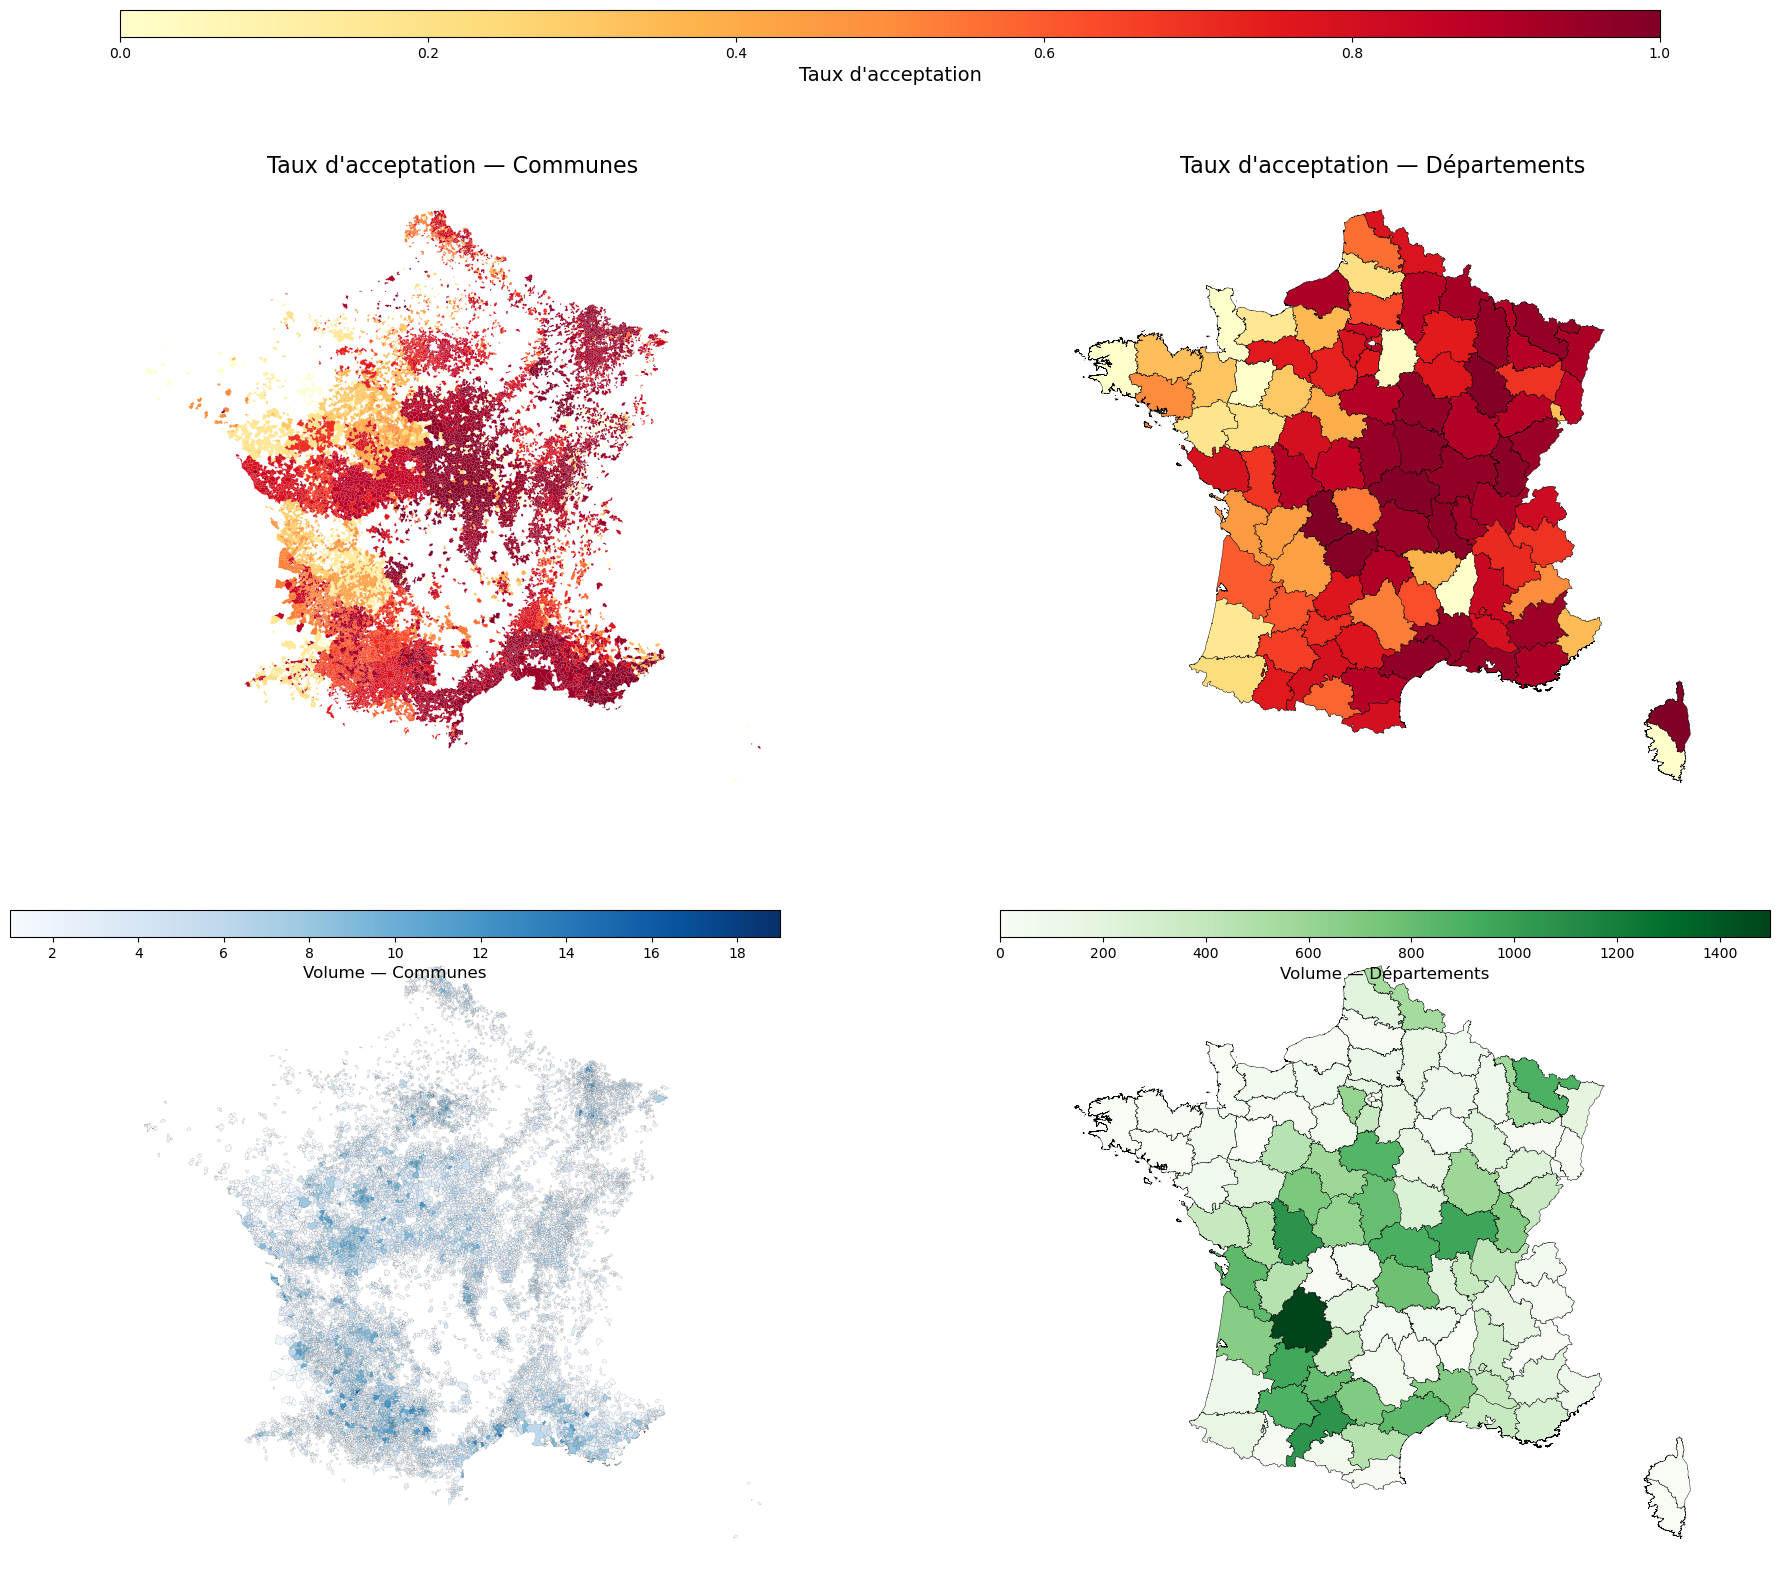

In [22]:
# --- IMPORTS ---
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import pyogrio

# --- PATH ---
LimitAdmin = r"C:/Users/HP/Desktop/ML for climate risk/ML-for-Climate-Risk/data/limite_admin/ADMIN-EXPRESS_4-0__GPKG_WGS84G_FRA_2025-10-15/ADMIN-EXPRESS/1_DONNEES_LIVRAISON_2025-10-00141/ADE_4-0_GPKG_WGS84G_FRA-ED2025-10-15/ADE_4-0_GPKG_WGS84G_FRA-ED2025-10-15.gpkg"

# ---------------------------------------------------------------------
# 1. CHARGEMENT DES COUCHES GEO
# ---------------------------------------------------------------------
gdf_commune = gpd.read_file(LimitAdmin, layer="commune").to_crs(2154)
gdf_dept = gpd.read_file(LimitAdmin, layer="departement").to_crs(2154)

# ---------------------------------------------------------------------
# 2. PRÉPARATION DES DONNÉES
# ---------------------------------------------------------------------
df1 = df.copy()

# -- création du code département --
df1["N° Insee"] = df1["N° Insee"].astype(str).str.zfill(5)
df1["code_dept"] = df1["N° Insee"].astype(str).str[:2]
df1.loc[df1["N° Insee"].astype(str).str.startswith("2A"), "code_dept"] = "2A"
df1.loc[df1["N° Insee"].astype(str).str.startswith("2B"), "code_dept"] = "2B"
df1["N° Insee"] = df1["N° Insee"].astype(str)

# -- COMMUNE (taux + volume) --
df_commune_last = (
    df1.groupby("N° Insee")
       .tail(1)[["N° Insee", "accept_rate_dep", "n_events"]]
)

# -- DÉPARTEMENT (taux + volume) --
df_dept_last = (
    df1.groupby("code_dept")
       .tail(1)[["code_dept", "accept_rate_dep", "total_dep_requests"]]
)

# ---------------------------------------------------------------------
# 3. MERGE AVEC LES FONDS DE CARTE
# ---------------------------------------------------------------------
# Commune
gdf_commune["code_insee"] = gdf_commune["code_insee"].astype(str)
gdf_map_commune = gdf_commune.merge(
    df_commune_last,
    left_on="code_insee",
    right_on="N° Insee",
    how="inner"
)

# Département
gdf_dept["code_insee"] = gdf_dept["code_insee"].astype(str)
gdf_map_dept = gdf_dept.merge(
    df_dept_last,
    left_on="code_insee",
    right_on="code_dept",
    how="inner"
)

# ---------------------------------------------------------------------
# 4. FIGURE 2×2
# ---------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(22, 18))

# ---------------------------------------------------------------------
# COLORBARS — Définition des échelles
# ---------------------------------------------------------------------

# Taux : une seule colorbar pour les deux premières cartes
vmin_rate = min(gdf_map_commune["accept_rate_dep"].min(),
                gdf_map_dept["accept_rate_dep"].min())
vmax_rate = max(gdf_map_commune["accept_rate_dep"].max(),
                gdf_map_dept["accept_rate_dep"].max())
rate_norm = mpl.colors.Normalize(vmin_rate, vmax_rate)
rate_cmap = mpl.cm.YlOrRd

# Volume communes
vmin_vol_comm = gdf_map_commune["n_events"].min()
vmax_vol_comm = gdf_map_commune["n_events"].max()
vol_comm_norm = mpl.colors.Normalize(vmin_vol_comm, vmax_vol_comm)
vol_comm_cmap = mpl.cm.Blues

# Volume départements
vmin_vol_dept = gdf_map_dept["total_dep_requests"].min()
vmax_vol_dept = gdf_map_dept["total_dep_requests"].max()
vol_dept_norm = mpl.colors.Normalize(vmin_vol_dept, vmax_vol_dept)
vol_dept_cmap = mpl.cm.Greens


# ---------------------------------------------------------------------
# 1. TAUX — COMMUNES (haut gauche)
# ---------------------------------------------------------------------
gdf_map_commune.plot(
    column="accept_rate_dep",
    cmap=rate_cmap,
    norm=rate_norm,
    edgecolor="none",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Taux d'acceptation — Communes", fontsize=16)
axes[0, 0].axis("off")

# ---------------------------------------------------------------------
# 2. TAUX — DÉPARTEMENTS (haut droite)
# ---------------------------------------------------------------------
gdf_map_dept.plot(
    column="accept_rate_dep",
    cmap=rate_cmap,
    norm=rate_norm,
    edgecolor="black",
    linewidth=0.3,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Taux d'acceptation — Départements", fontsize=16)
axes[0, 1].axis("off")

# ---------------------------------------------------------------------
# 3. VOLUME — COMMUNES (bas gauche)
# ---------------------------------------------------------------------
gdf_map_commune.plot(
    column="n_events",
    cmap=vol_comm_cmap,
    norm=vol_comm_norm,
    edgecolor="black",
    linewidth=0.05,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Volume des demandes — Communes", fontsize=16)
axes[1, 0].axis("off")

# ---------------------------------------------------------------------
# 4. VOLUME — DÉPARTEMENTS (bas droite)
# ---------------------------------------------------------------------
gdf_map_dept.plot(
    column="total_dep_requests",
    cmap=vol_dept_cmap,
    norm=vol_dept_norm,
    edgecolor="black",
    linewidth=0.3,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Volume des demandes — Départements", fontsize=16)
axes[1, 1].axis("off")


# ---------------------------------------------------------------------
# COLORBAR 1 : unique pour les taux (communes + départements)
# ---------------------------------------------------------------------
cbar1 = fig.add_axes([0.15, 0.96, 0.70, 0.015])  # fine, horizontale
mpl.colorbar.ColorbarBase(
    cbar1,
    cmap=rate_cmap,
    norm=rate_norm,
    orientation='horizontal'
).set_label("Taux d'acceptation", fontsize=14)

# ---------------------------------------------------------------------
# COLORBAR 2 : volumes COMMUNES
# ---------------------------------------------------------------------
cbar2 = fig.add_axes([0.10, 0.46, 0.35, 0.015])
mpl.colorbar.ColorbarBase(
    cbar2,
    cmap=vol_comm_cmap,
    norm=vol_comm_norm,
    orientation='horizontal'
).set_label("Volume — Communes", fontsize=12)

# ---------------------------------------------------------------------
# COLORBAR 3 : volumes DÉPARTEMENTS
# ---------------------------------------------------------------------
cbar3 = fig.add_axes([0.55, 0.46, 0.35, 0.015])
mpl.colorbar.ColorbarBase(
    cbar3,
    cmap=vol_dept_cmap,
    norm=vol_dept_norm,
    orientation='horizontal'
).set_label("Volume — Départements", fontsize=12)

plt.show()


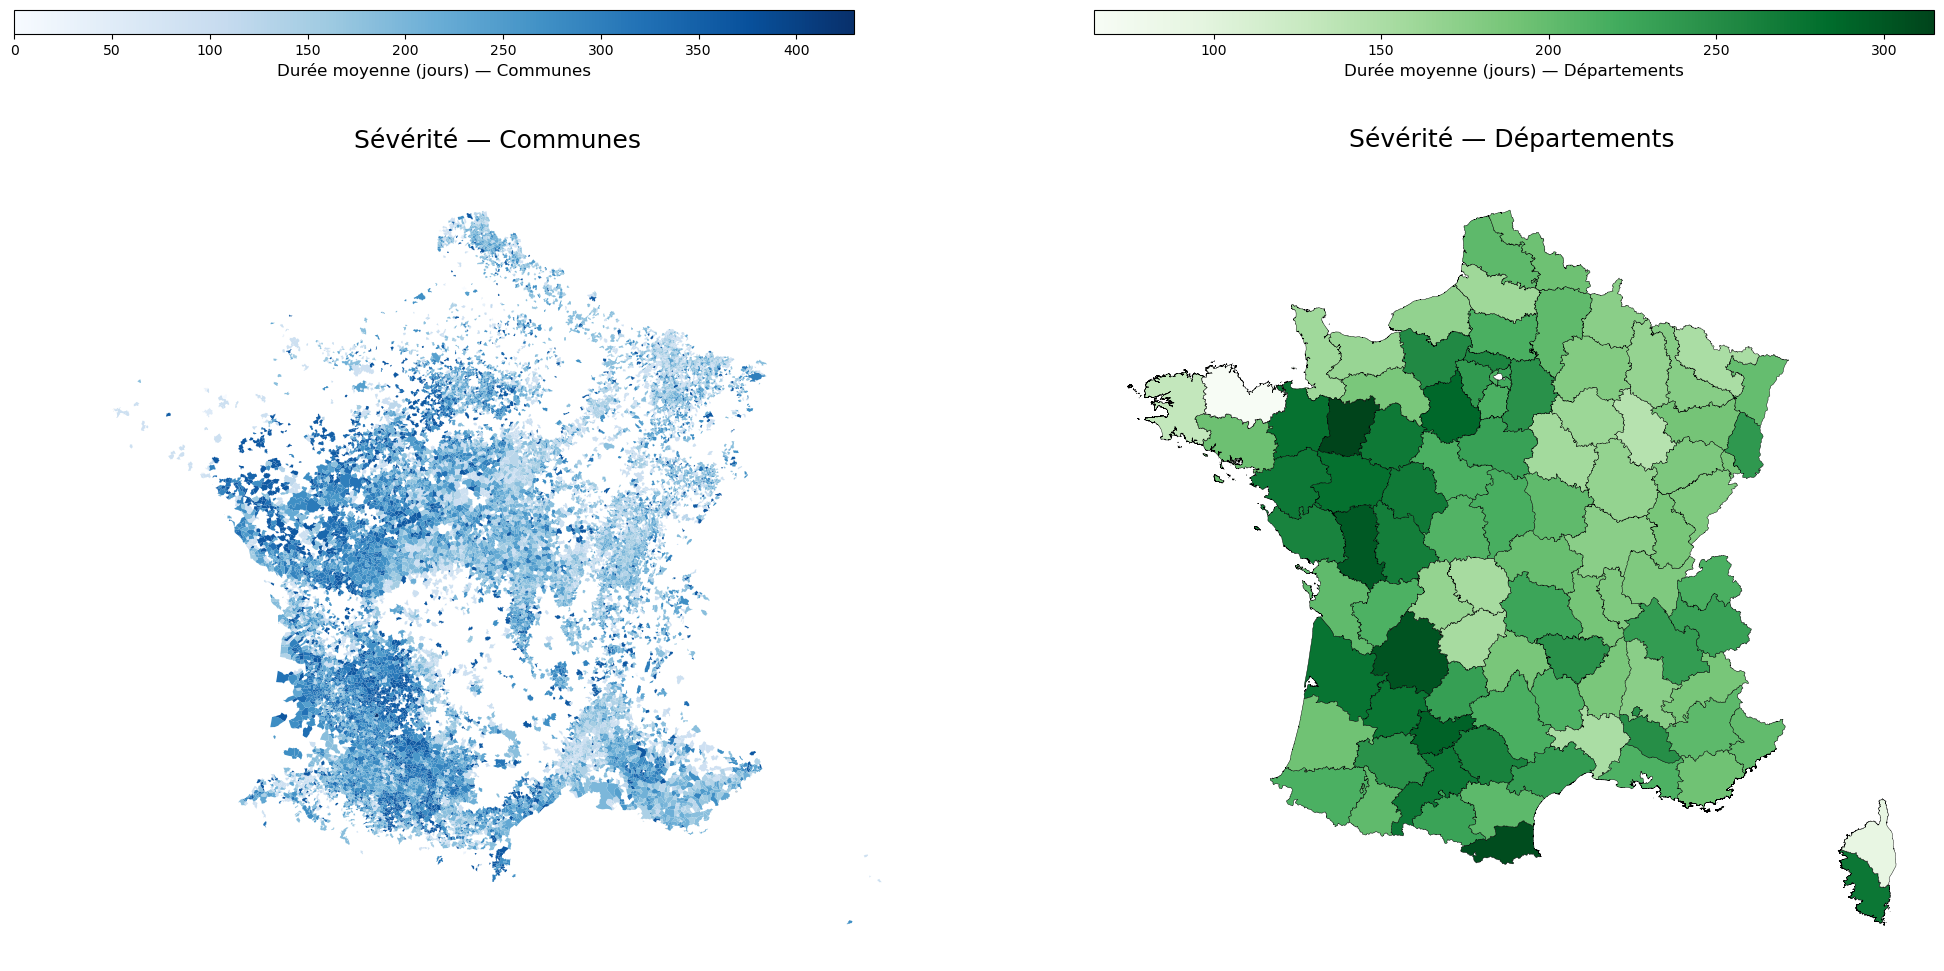

In [24]:
# --- IMPORTS ---
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import pyogrio

# --- PATH ---
LimitAdmin = r"C:/Users/HP/Desktop/ML for climate risk/ML-for-Climate-Risk/data/limite_admin/ADMIN-EXPRESS_4-0__GPKG_WGS84G_FRA_2025-10-15/ADMIN-EXPRESS/1_DONNEES_LIVRAISON_2025-10-00141/ADE_4-0_GPKG_WGS84G_FRA-ED2025-10-15/ADE_4-0_GPKG_WGS84G_FRA-ED2025-10-15.gpkg"

# ---------------------------------------------------------------------
# 1. GEO DATA
# ---------------------------------------------------------------------
gdf_commune = gpd.read_file(LimitAdmin, layer="commune").to_crs(2154)
gdf_dept    = gpd.read_file(LimitAdmin, layer="departement").to_crs(2154)

# ---------------------------------------------------------------------
# 2. PREPARATION DES DONNÉES
# ---------------------------------------------------------------------
df1 = df.copy()
df1["N° Insee"] = df1["N° Insee"].astype(str).str.zfill(5)
# Code département
df1["code_dept"] = df1["N° Insee"].str[:2]
df1.loc[df1["N° Insee"].str.startswith("2A"), "code_dept"] = "2A"
df1.loc[df1["N° Insee"].str.startswith("2B"), "code_dept"] = "2B"

# ---------------------------------------------------------------------
# 3. MOYENNE avg_duration_days PAR COMMUNE ET PAR DÉPARTEMENT
# ---------------------------------------------------------------------
df_commune_avg = df1.groupby("N° Insee")["avg_duration_days"].mean().reset_index()
df_dept_avg    = df1.groupby("code_dept")["avg_duration_days"].mean().reset_index()

# ---------------------------------------------------------------------
# 4. MERGE AVEC FONDS GEO
# ---------------------------------------------------------------------
# Commune
gdf_commune["code_insee"] = gdf_commune["code_insee"].astype(str)
gdf_map_commune = gdf_commune.merge(df_commune_avg, left_on="code_insee", right_on="N° Insee")

# Département
gdf_dept["code_insee"] = gdf_dept["code_insee"].astype(str)
gdf_map_dept = gdf_dept.merge(df_dept_avg, left_on="code_insee", right_on="code_dept")

# ---------------------------------------------------------------------
# 5. FIGURE : 1 ligne, 2 cartes + 2 colorbars
# ---------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(24, 12))
plt.subplots_adjust(top=0.88)  # --- ajoute de l'espace en haut ---

# Couleurs
cmap_commune = mpl.cm.Blues
cmap_dept    = mpl.cm.Greens

# PLAGE COMMUNE
vmin_comm = gdf_map_commune["avg_duration_days"].min()
vmax_comm = gdf_map_commune["avg_duration_days"].max()
norm_comm = mpl.colors.Normalize(vmin_comm, vmax_comm)

# PLAGE DÉPARTEMENT
vmin_dept = gdf_map_dept["avg_duration_days"].min()
vmax_dept = gdf_map_dept["avg_duration_days"].max()
norm_dept = mpl.colors.Normalize(vmin_dept, vmax_dept)

# ---------------------------------------------------------------------
# CARTE COMMUNE (à gauche)
# ---------------------------------------------------------------------
gdf_map_commune.plot(
    column="avg_duration_days",
    cmap=cmap_commune,
    norm=norm_comm,
    edgecolor="none",
    ax=axes[0]
)
axes[0].set_title("Sévérité — Communes", fontsize=18, pad=20)
axes[0].axis("off")

# Colorbar commune
cax1 = fig.add_axes([0.10, 0.94, 0.35, 0.02])  # --- plus haut ---
mpl.colorbar.ColorbarBase(
    cax1,
    cmap=cmap_commune,
    norm=norm_comm,
    orientation='horizontal'
).set_label("Durée moyenne (jours) — Communes", fontsize=12)

# ---------------------------------------------------------------------
# CARTE DÉPARTEMENT (à droite)
# ---------------------------------------------------------------------
gdf_map_dept.plot(
    column="avg_duration_days",
    cmap=cmap_dept,
    norm=norm_dept,
    edgecolor="black",
    linewidth=0.3,
    ax=axes[1]
)
axes[1].set_title("Sévérité — Départements", fontsize=18, pad=20)
axes[1].axis("off")

# Colorbar département
cax2 = fig.add_axes([0.55, 0.94, 0.35, 0.02])  # --- plus haut ---
mpl.colorbar.ColorbarBase(
    cax2,
    cmap=cmap_dept,
    norm=norm_dept,
    orientation='horizontal'
).set_label("Durée moyenne (jours) — Départements", fontsize=12)

plt.show()


In [11]:
import pandas as pd

# 1. Charger tes données
# Remplace ceci par ton propre chargement (csv, parquet, etc.)
# Exemple :
# df = pd.read_csv("ton_fichier.csv")

# Ici j'assume que ton DataFrame s'appelle déjà df
# et qu'il contient les colonnes mentionnées.

# 2. Extraire l'année à partir de event_period (format 'YYYY-MM')
df["year"] = df["event_period"].astype(str).str.slice(0, 4).astype(int)

# 3. Année minimale et maximale dans la base
year_min = df["year"].min()
year_max = df["year"].max()
print(f"Année minimale dans la base: {year_min}")
print(f"Année maximale dans la base: {year_max}")

# 4. Communes avec au moins 2 années distinctes
communes_multi_annees = (
    df.groupby("N° Insee")["year"]
      .nunique()
      .reset_index(name="n_years")
)

communes_multi_annees = communes_multi_annees[communes_multi_annees["n_years"] >= 2]
print("\nNombre de communes avec au moins 2 années distinctes:")
print(len(communes_multi_annees))

# 5. Lister les années par commune
years_by_commune = (
    df.groupby("N° Insee")["year"]
      .unique()
      .reset_index(name="years_list")
)

print("\nExemple des années par commune:")
print(years_by_commune.head())

# 6. (Optionnel) Construire un panel équilibré sur tout l'intervalle observé
# i.e. communes présentes chaque année entre year_min et year_max

years_target = set(range(year_min, year_max + 1))

panel_equilibre = (
    df.groupby("N° Insee")["year"]
      .agg(lambda x: set(x) == years_target)
      .reset_index(name="is_balanced")
)

panel_equilibre = panel_equilibre[panel_equilibre["is_balanced"]]

print("\nNombre de communes avec panel équilibré sur tout l'intervalle:")
print(len(panel_equilibre))

# 7. DataFrame restreint au panel équilibré
communes_balanced = panel_equilibre["N° Insee"]
df_panel = df[df["N° Insee"].isin(communes_balanced)].copy()

print("\nAperçu du panel équilibré:")
print(df_panel.head())

# Si tu veux sauvegarder ce panel:
# df_panel.to_csv("panel_equilibre.csv", index=False)


Année minimale dans la base: 2007
Année maximale dans la base: 2024

Nombre de communes avec au moins 2 années distinctes:
9732

Exemple des années par commune:
  N° Insee                years_list
0    71177        [2015, 2018, 2022]
1    71179                    [2019]
2    71182  [2017, 2018, 2019, 2022]
3    71183                    [2019]
4    71184              [2015, 2018]

Nombre de communes avec panel équilibré sur tout l'intervalle:
0

Aperçu du panel équilibré:
Empty DataFrame
Columns: [N° Insee, Nom de la commune, event_period, Decision_text, recognized, Dernier_lag_decision, n_events, nbr_demandes_passees, nbr_demandes_passees_acceptées, avg_duration_days, first_date_debut, last_date_fin, Code_peril, Departement, NB_DEP, dep_recog_last5, Catnat_intensity_dep, accept_rate_dep, dep_ever_recog, dep_delay_median, total_dep_requests, years_all_communes_recognized_before, argile_niveau, swi_unif_min, year]
Index: []

[0 rows x 25 columns]


In [12]:
# Comptage du nombre de communes distinctes par année
communes_par_annee = (
    df.groupby("year")["N° Insee"]
      .nunique()
      .reset_index(name="n_communes")
      .sort_values("n_communes", ascending=False)
)

print("\nNombre de communes distinctes par année (tri décroissant) :")
print(communes_par_annee)

# Années avec le maximum de communes
max_communes = communes_par_annee["n_communes"].max()
annees_max_communes = communes_par_annee[communes_par_annee["n_communes"] == max_communes]

print("\nAnnée(s) avec le plus de communes :")
print(annees_max_communes)



Nombre de communes distinctes par année (tri décroissant) :
    year  n_communes
14  2022        9377
11  2019        6232
10  2018        5795
12  2020        5329
15  2023        4200
9   2017        3003
8   2016        2446
7   2015        2029
13  2021        1709
16  2024        1629
5   2013         472
6   2014         311
4   2012          96
1   2009          10
2   2010           2
0   2007           1
3   2011           1

Année(s) avec le plus de communes :
    year  n_communes
14  2022        9377


In [ ]:
# --- IMPORTS --- cartes_taux_acceptation
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import pyogrio

# --- PATH ---
LimitAdmin = r"C:/Users/HP/Desktop/ML for climate risk/ML-for-Climate-Risk/data/limite_admin/ADMIN-EXPRESS_4-0__GPKG_WGS84G_FRA_2025-10-15/ADMIN-EXPRESS/1_DONNEES_LIVRAISON_2025-10-00141/ADE_4-0_GPKG_WGS84G_FRA-ED2025-10-15/ADE_4-0_GPKG_WGS84G_FRA-ED2025-10-15.gpkg"

# Chargement des fonds de carte (une seule fois)
gdf_commune = gpd.read_file(LimitAdmin, layer="commune").to_crs(2154)
gdf_dept    = gpd.read_file(LimitAdmin, layer="departement").to_crs(2154)
gdf_commune["code_insee"] = gdf_commune["code_insee"].astype(str)
gdf_dept["code_insee"] = gdf_dept["code_insee"].astype(str)

def cartes_taux_acceptation(annees_list):
    """
    Affiche les cartes du taux d'acceptation pour les années données
    annees_list : list[int] ex: [2024] ou [2023, 2024]
    """
    df1 = df.copy()
    df1["year"] = df1["event_period"].astype(str).str.slice(0, 4).astype(int)
    
    for annee in annees_list:
        print(f"\n--- TRAITEMENT ANNÉE {annee} ---")
        
        # Filtrer l'année
        df_annee = df1[df1["year"] == annee].copy()
        
        # Création code département
        df_annee["N° Insee"] = df_annee["N° Insee"].astype(str).str.zfill(5)
        df_annee["code_dept"] = df_annee["N° Insee"].str[:2]
        df_annee.loc[df_annee["N° Insee"].str.startswith("2A"), "code_dept"] = "2A"
        df_annee.loc[df_annee["N° Insee"].str.startswith("2B"), "code_dept"] = "2B"
        
        # Agrégations
        df_commune = (
            df_annee.sort_values("event_period")
                   .groupby("N° Insee")
                   .tail(1)[["N° Insee", "accept_rate_dep"]]
        )
        df_dept = (
            df_annee.sort_values("event_period")
                   .groupby("code_dept")
                   .tail(1)[["code_dept", "accept_rate_dep"]]
        )
        
        # Merge
        gdf_map_commune = gdf_commune.merge(df_commune, left_on="code_insee", right_on="N° Insee", how="inner")
        gdf_map_dept = gdf_dept.merge(df_dept, left_on="code_insee", right_on="code_dept", how="inner")
        
        # Figure 1x2
        fig, axes = plt.subplots(1, 2, figsize=(22, 10))
        
        # Échelle commune
        vmin_rate = min(gdf_map_commune["accept_rate_dep"].min(), gdf_map_dept["accept_rate_dep"].min())
        vmax_rate = max(gdf_map_commune["accept_rate_dep"].max(), gdf_map_dept["accept_rate_dep"].max())
        rate_norm = mpl.colors.Normalize(vmin_rate, vmax_rate)
        rate_cmap = mpl.cm.YlOrRd
        
        # Communes
        gdf_map_commune.plot(column="accept_rate_dep", cmap=rate_cmap, norm=rate_norm,
                           edgecolor="none", ax=axes[0])
        axes[0].set_title(f"Taux d'acceptation {annee} — Communes", fontsize=16)
        axes[0].axis("off")
        
        # Départements
        gdf_map_dept.plot(column="accept_rate_dep", cmap=rate_cmap, norm=rate_norm,
                         edgecolor="black", linewidth=0.3, ax=axes[1])
        axes[1].set_title(f"Taux d'acceptation {annee} — Départements", fontsize=16)
        axes[1].axis("off")
        
        # Colorbar
        cbar_ax = fig.add_axes([0.15, 0.05, 0.70, 0.02])
        cb = mpl.colorbar.ColorbarBase(cbar_ax, cmap=rate_cmap, norm=rate_norm, orientation='horizontal')
        cb.set_label(f"Taux d'acceptation {annee}", fontsize=14)
        
        plt.tight_layout(rect=[0, 0.08, 1, 1])
        plt.show()

# ---------------------------------------------------------------------
# USAGE
# ---------------------------------------------------------------------
# Une seule année
# cartes_taux_acceptation([2024])

# Plusieurs années
# cartes_taux_acceptation([2023, 2024])
# cartes_taux_acceptation([2020, 2022, 2024])



--- TRAITEMENT ANNÉE 2007 ---


C:\Users\HP\AppData\Local\Temp\ipykernel_2164\4076935080.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])


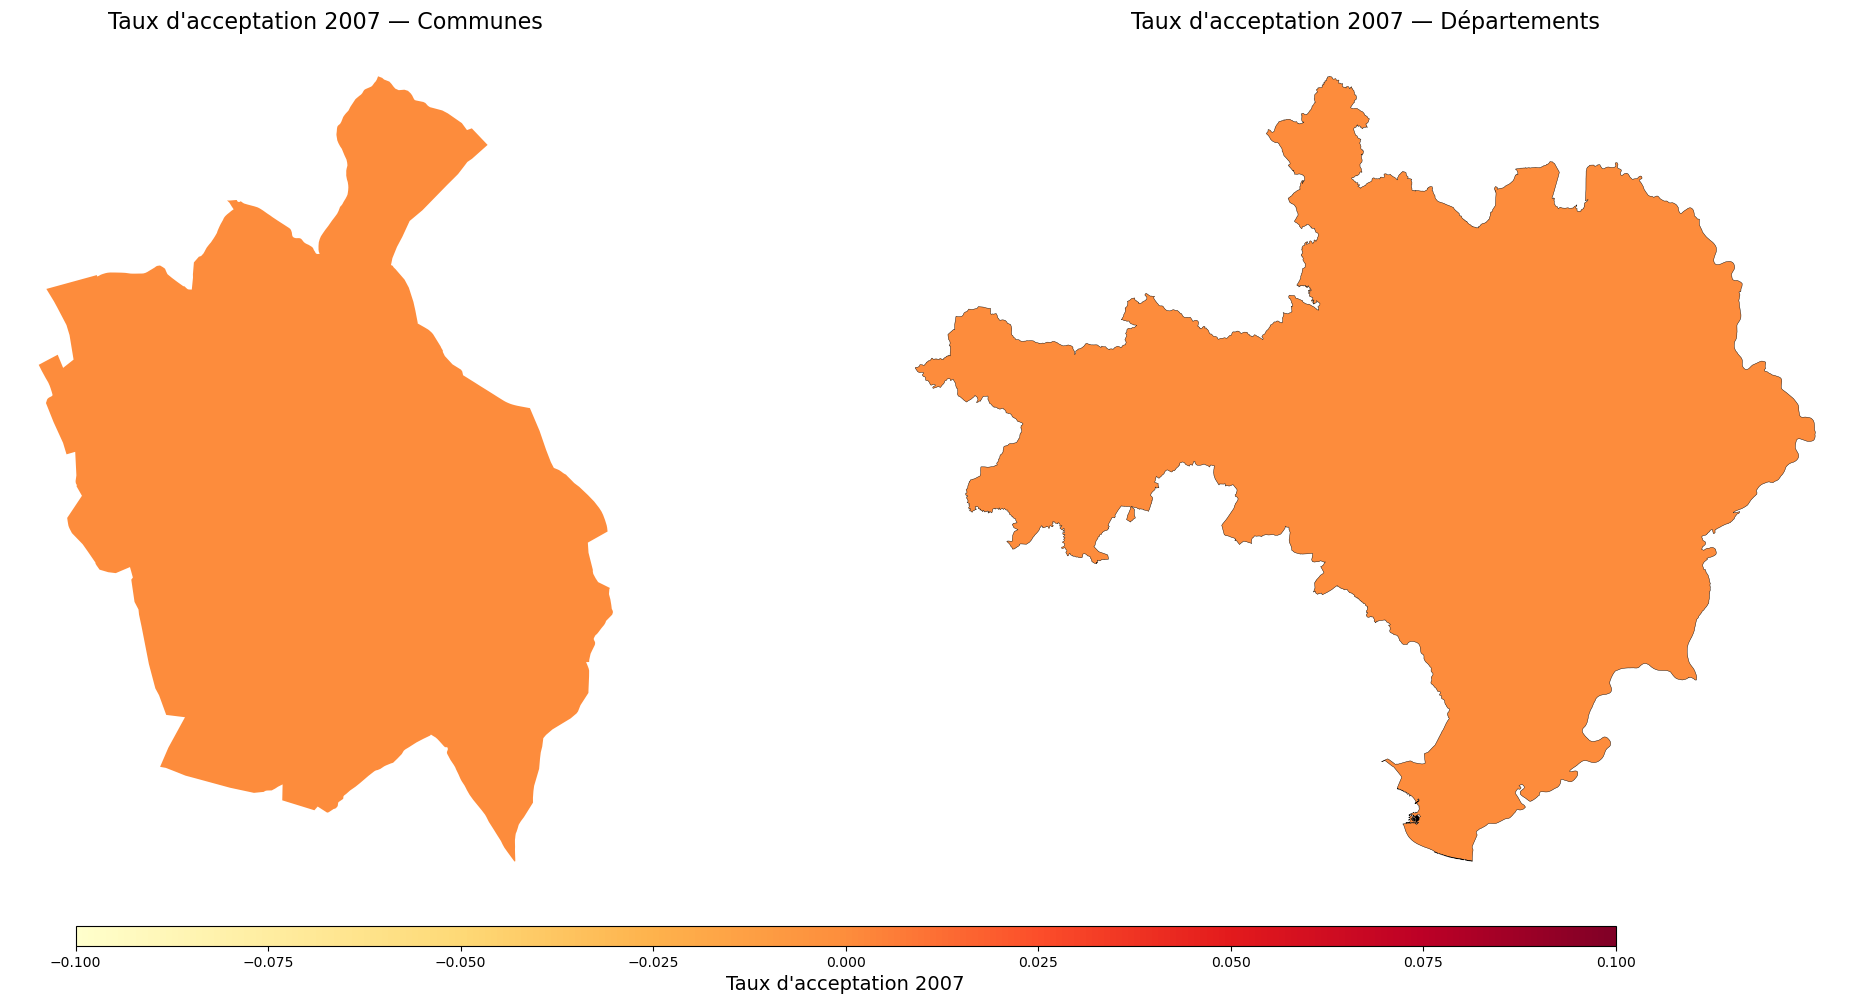


--- TRAITEMENT ANNÉE 2009 ---


C:\Users\HP\AppData\Local\Temp\ipykernel_2164\4076935080.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])


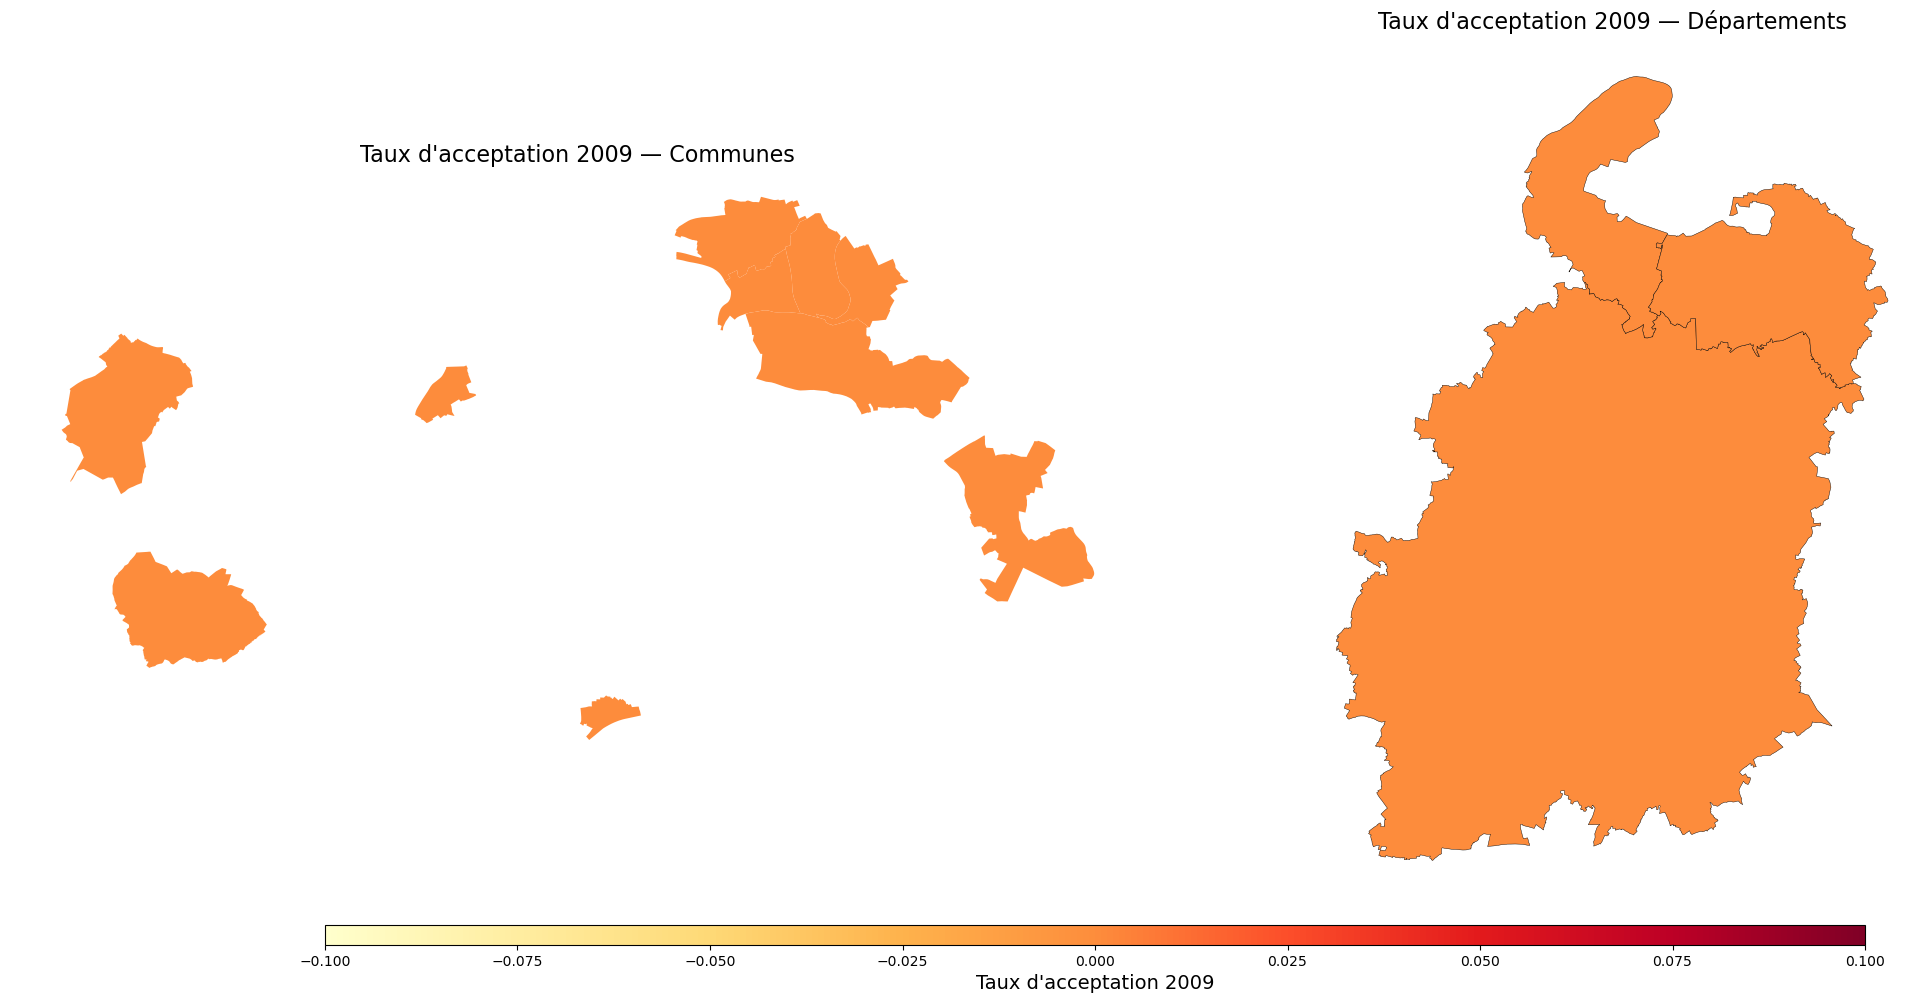


--- TRAITEMENT ANNÉE 2010 ---


C:\Users\HP\AppData\Local\Temp\ipykernel_2164\4076935080.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])


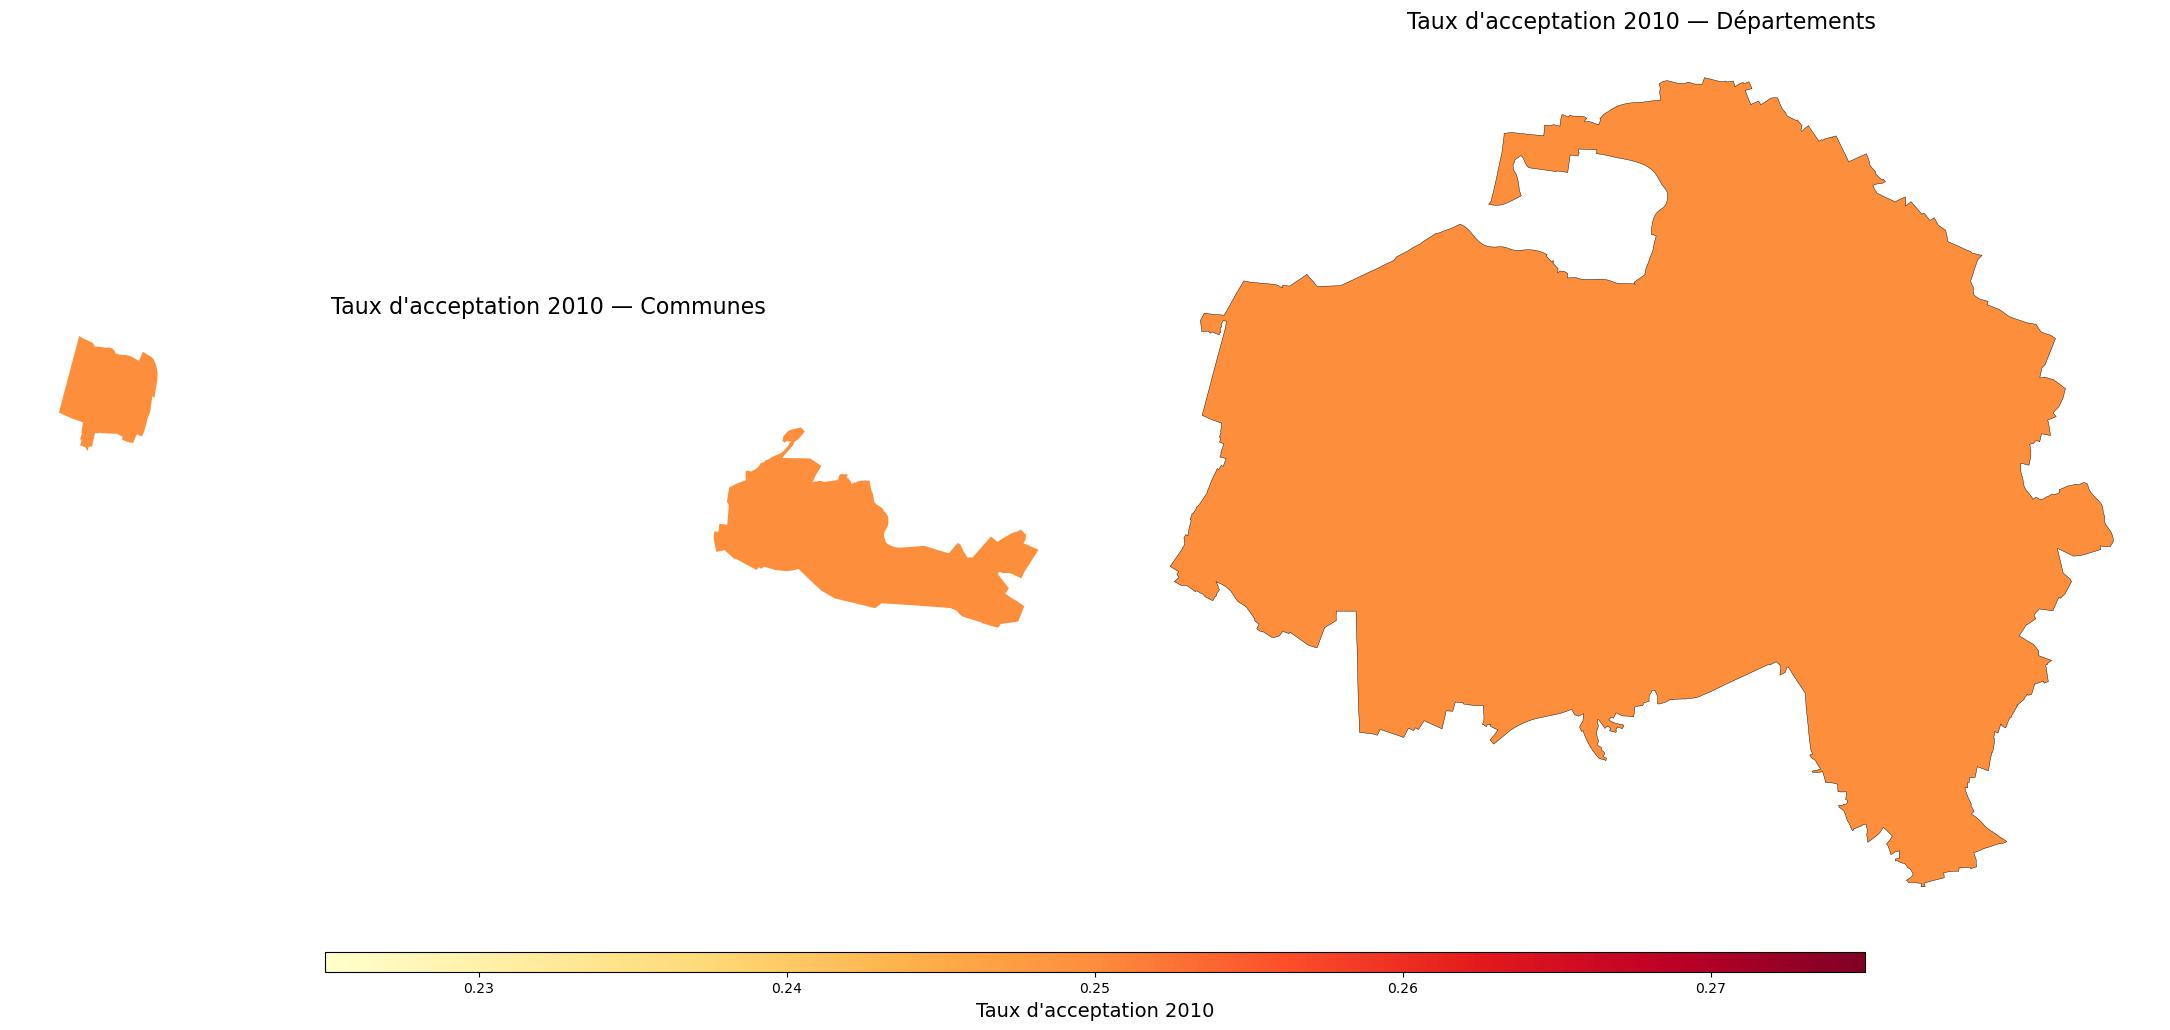


--- TRAITEMENT ANNÉE 2011 ---


C:\Users\HP\AppData\Local\Temp\ipykernel_2164\4076935080.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])


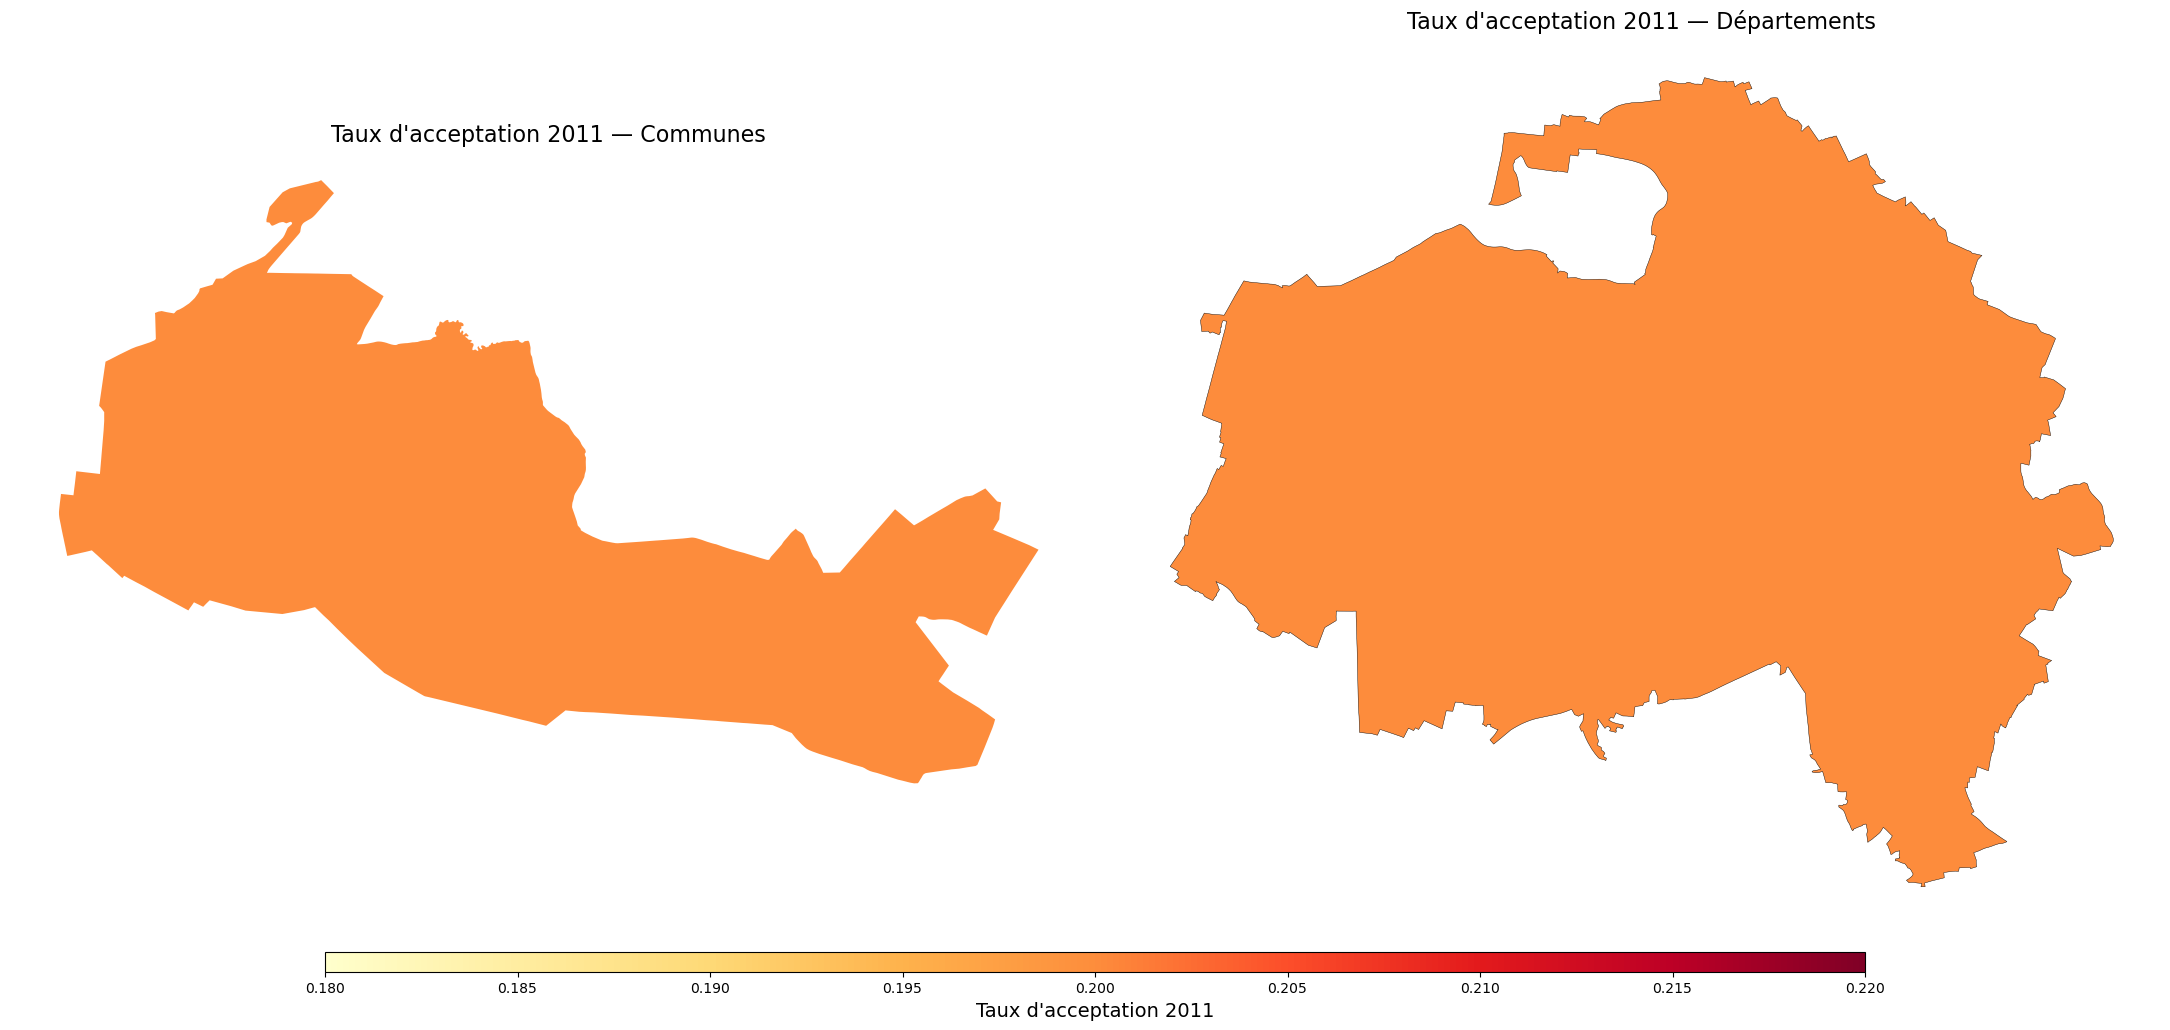


--- TRAITEMENT ANNÉE 2012 ---


C:\Users\HP\AppData\Local\Temp\ipykernel_2164\4076935080.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])


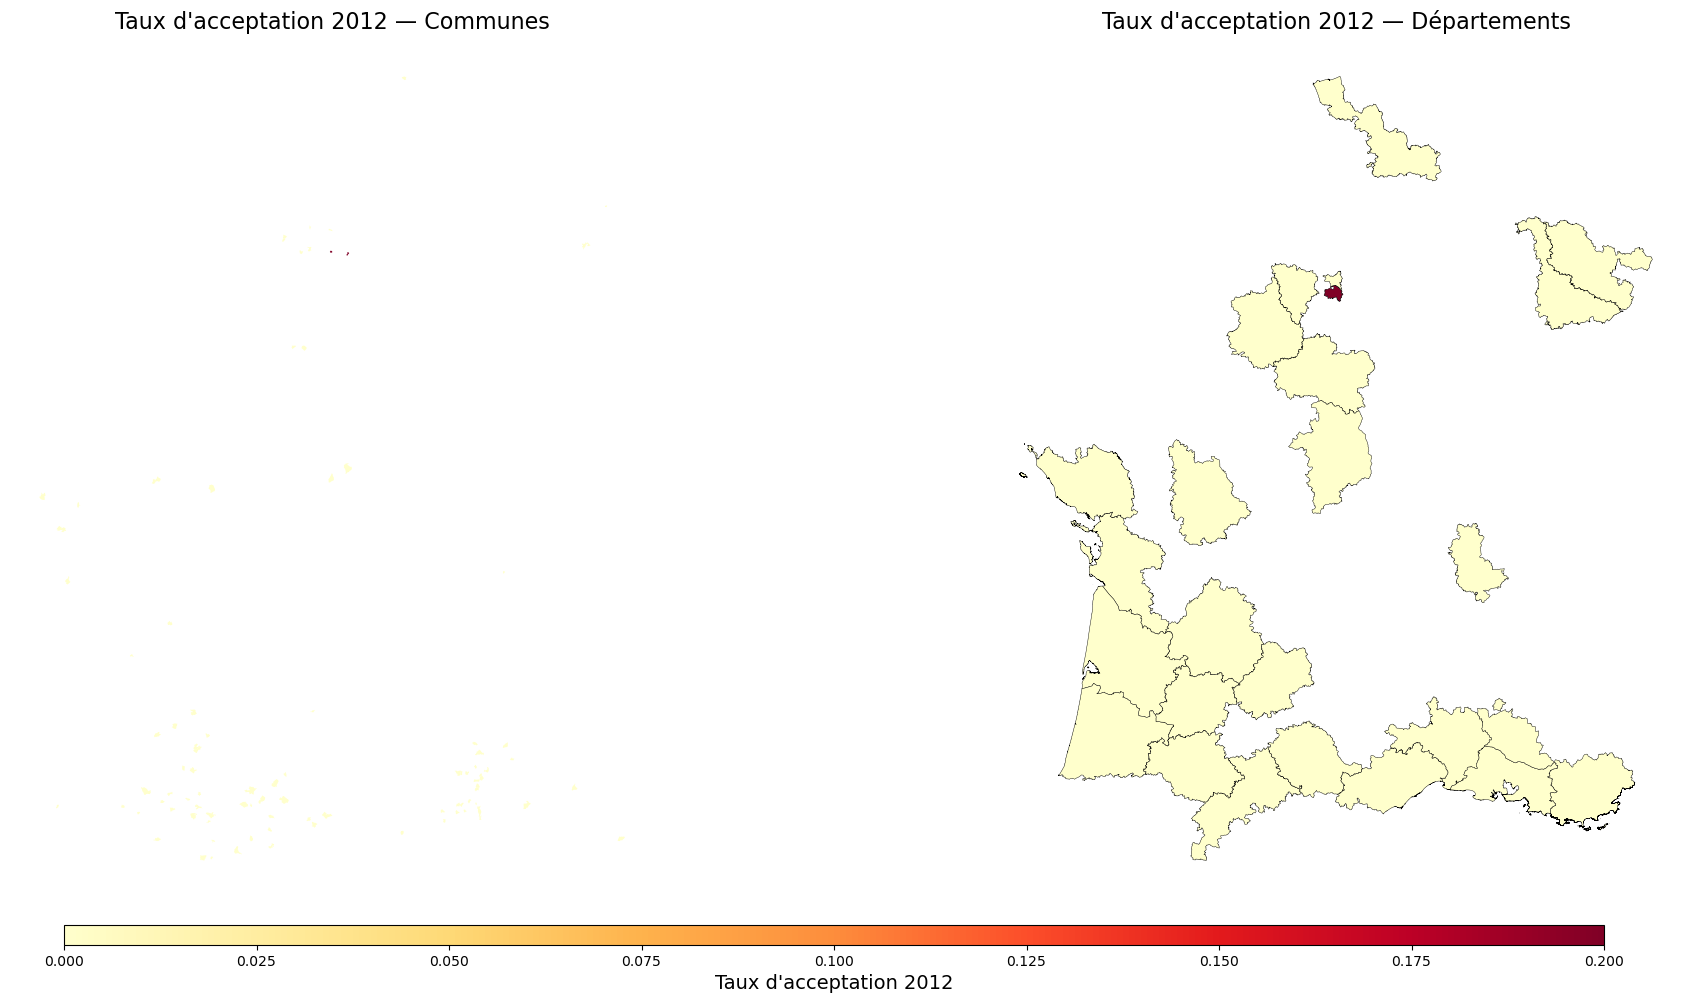


--- TRAITEMENT ANNÉE 2013 ---


C:\Users\HP\AppData\Local\Temp\ipykernel_2164\4076935080.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])


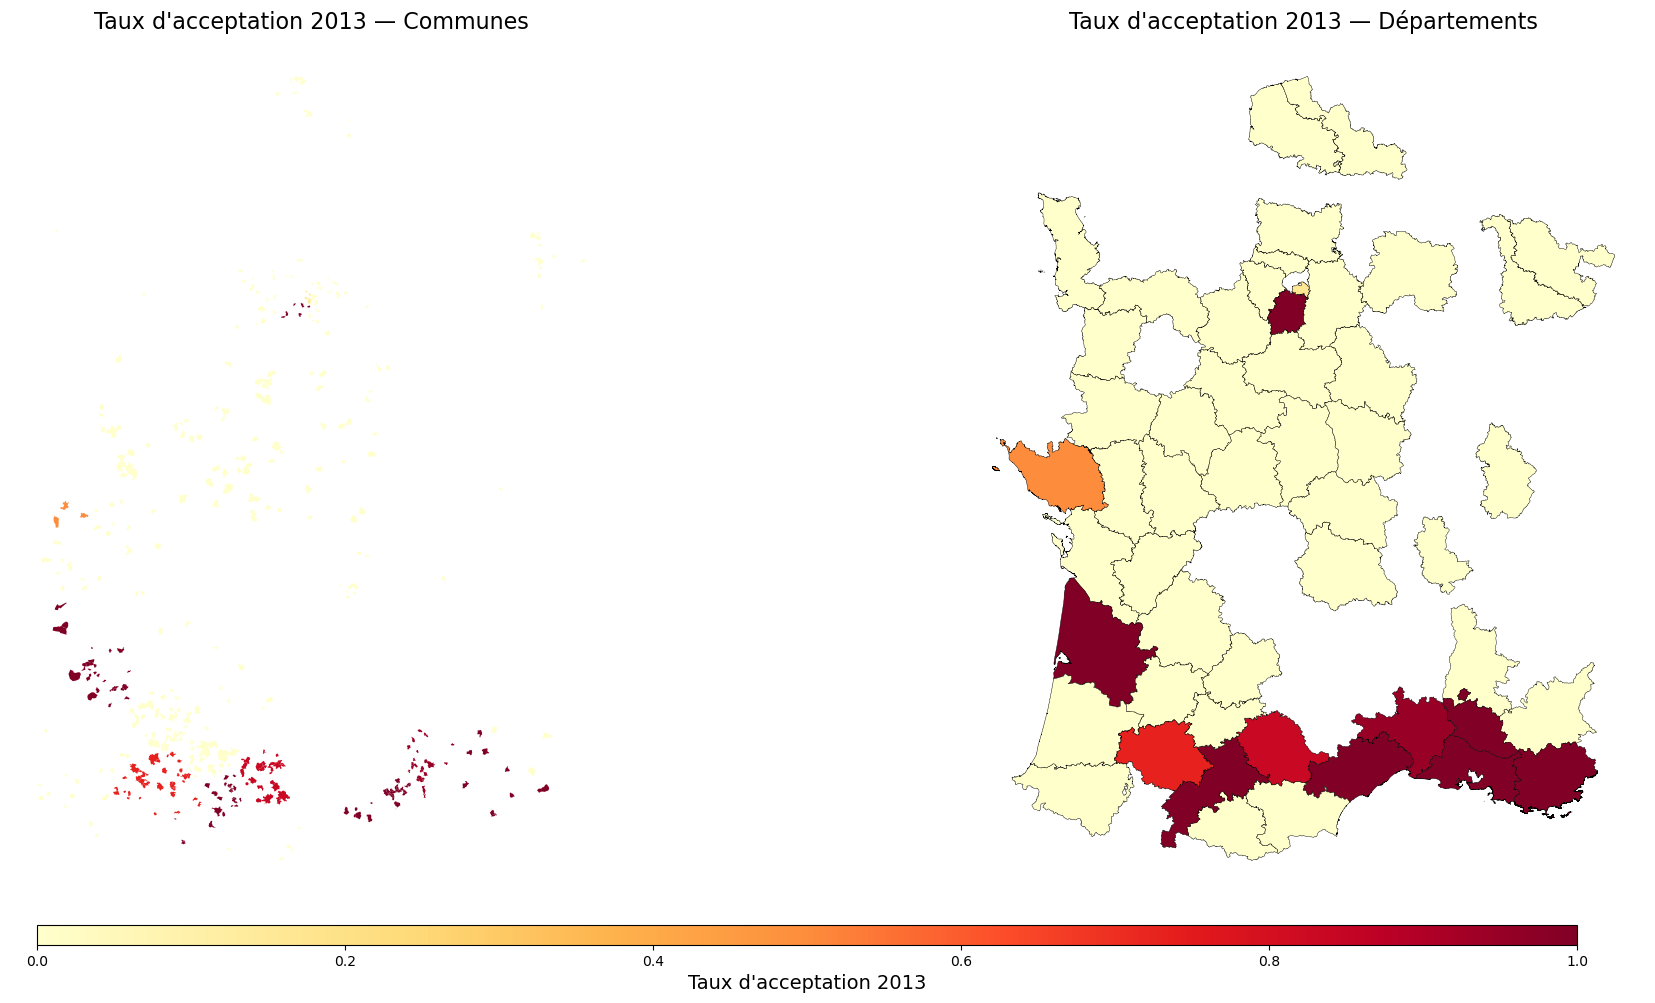


--- TRAITEMENT ANNÉE 2014 ---


C:\Users\HP\AppData\Local\Temp\ipykernel_2164\4076935080.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])


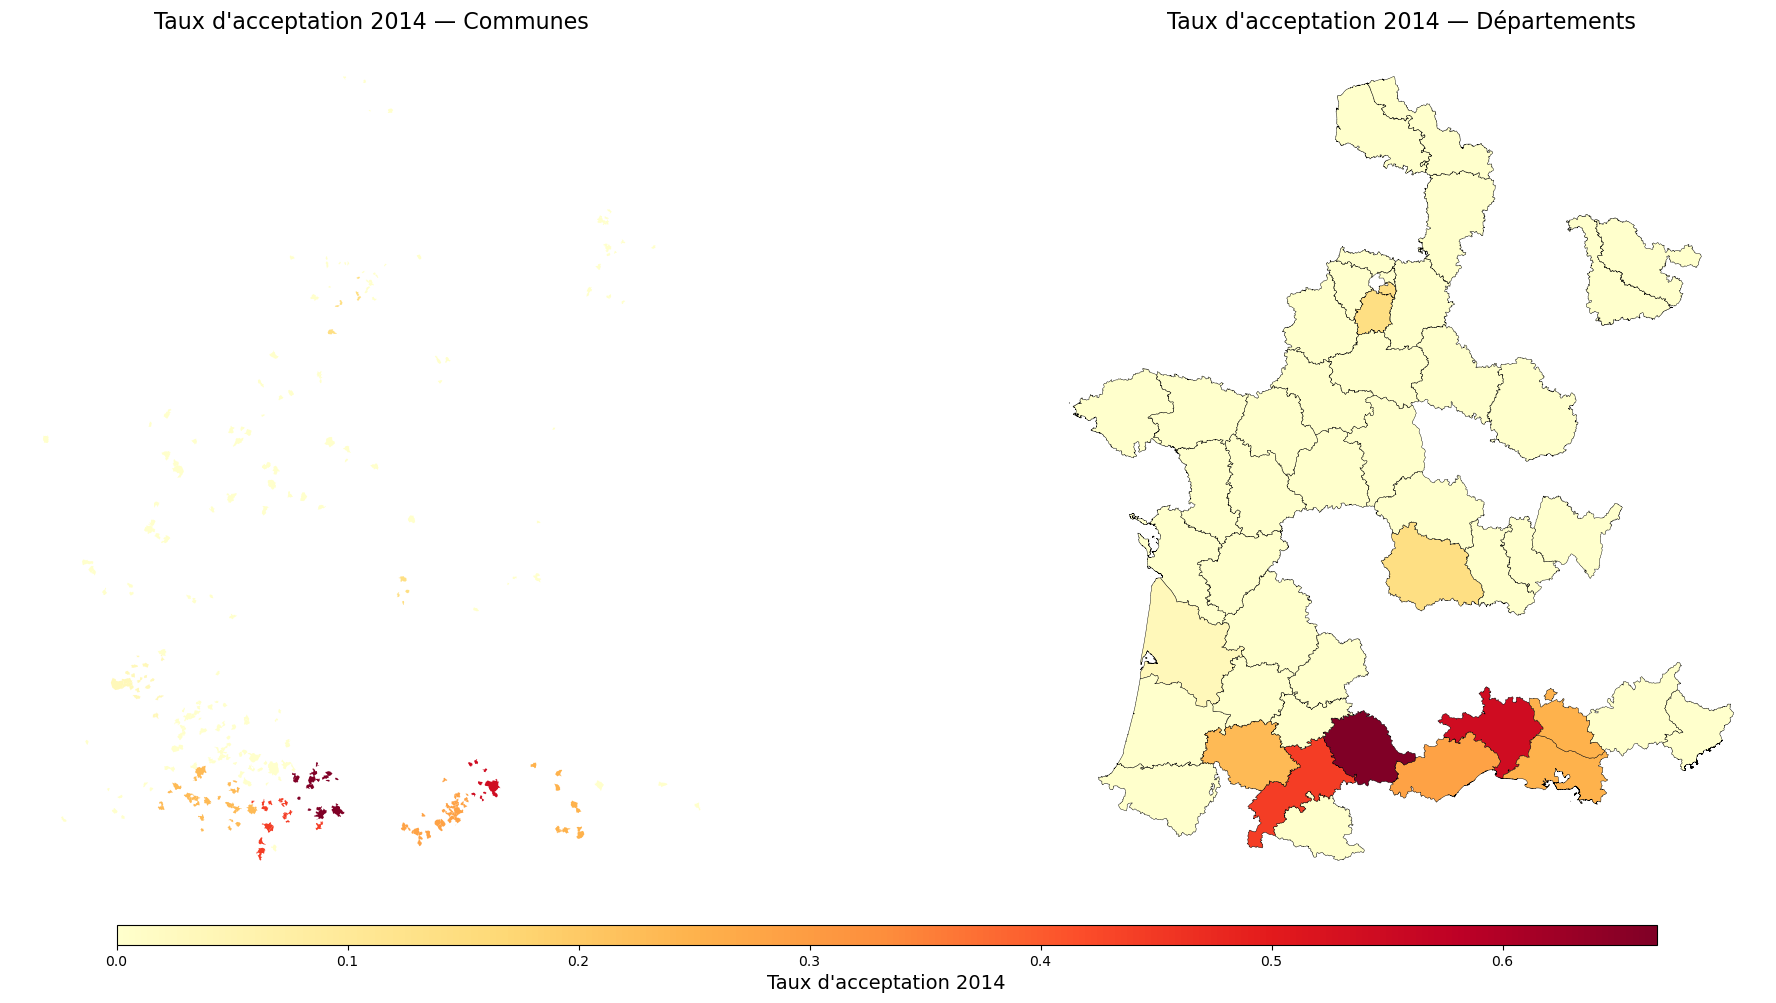


--- TRAITEMENT ANNÉE 2015 ---


C:\Users\HP\AppData\Local\Temp\ipykernel_2164\4076935080.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])


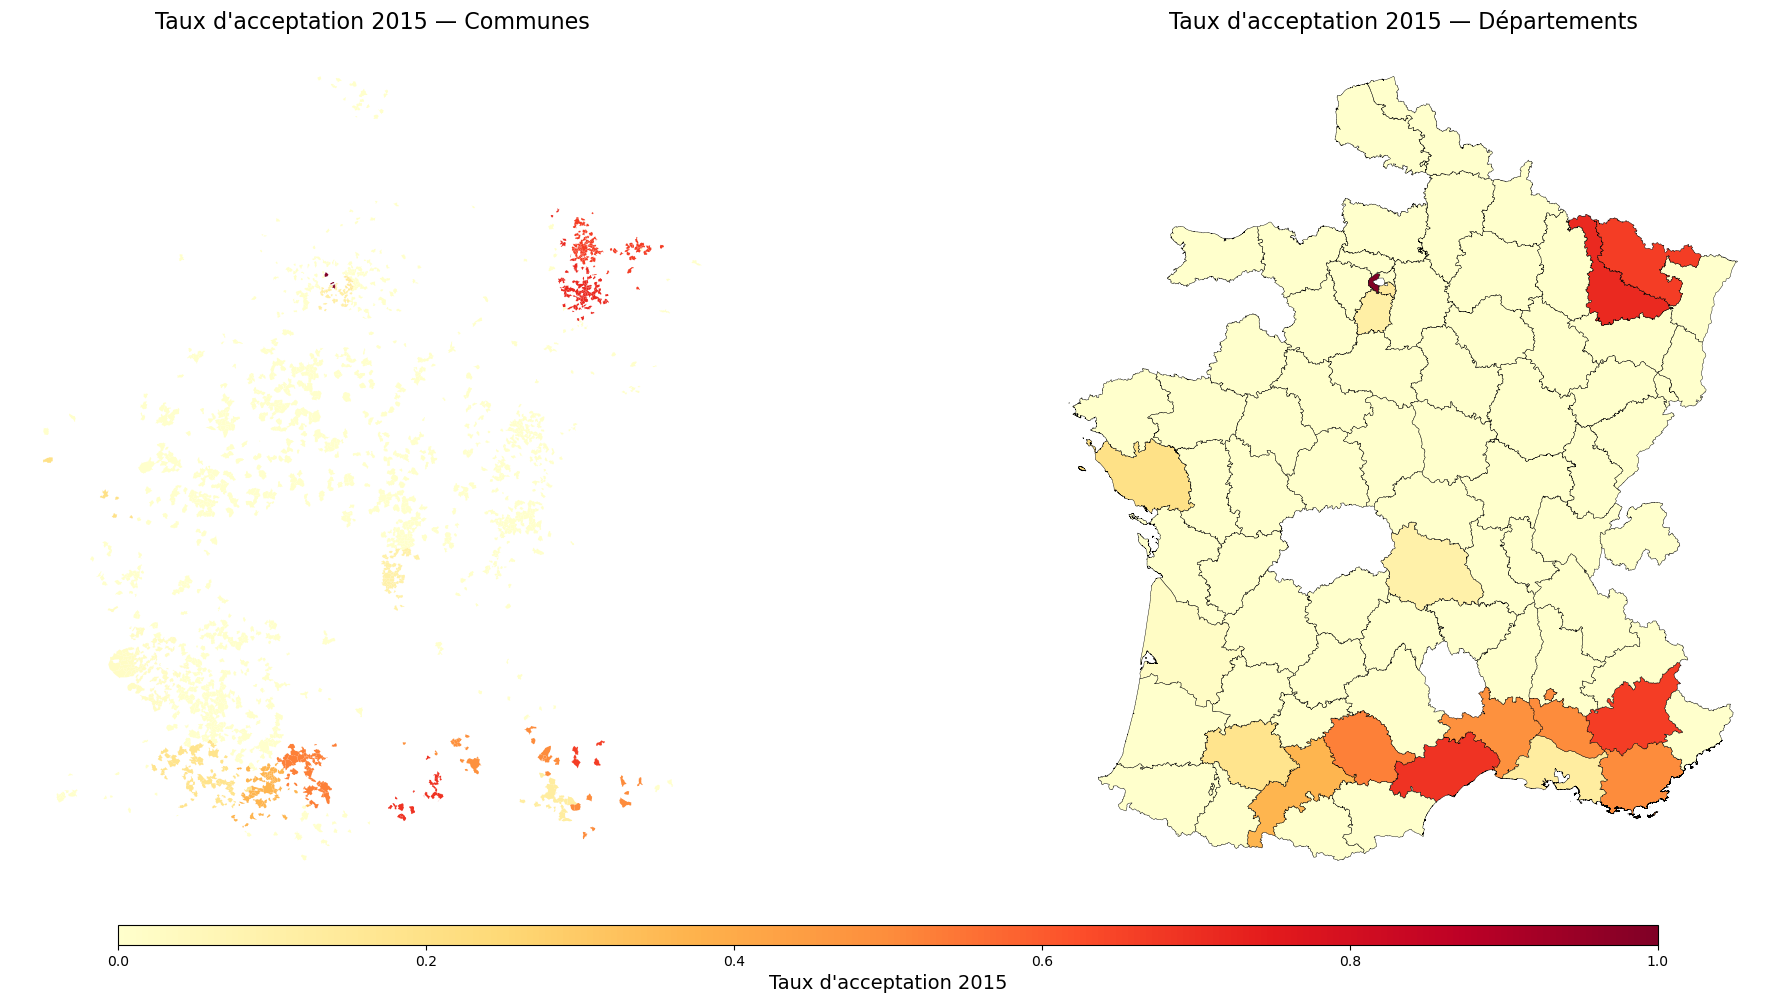


--- TRAITEMENT ANNÉE 2016 ---


C:\Users\HP\AppData\Local\Temp\ipykernel_2164\4076935080.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])


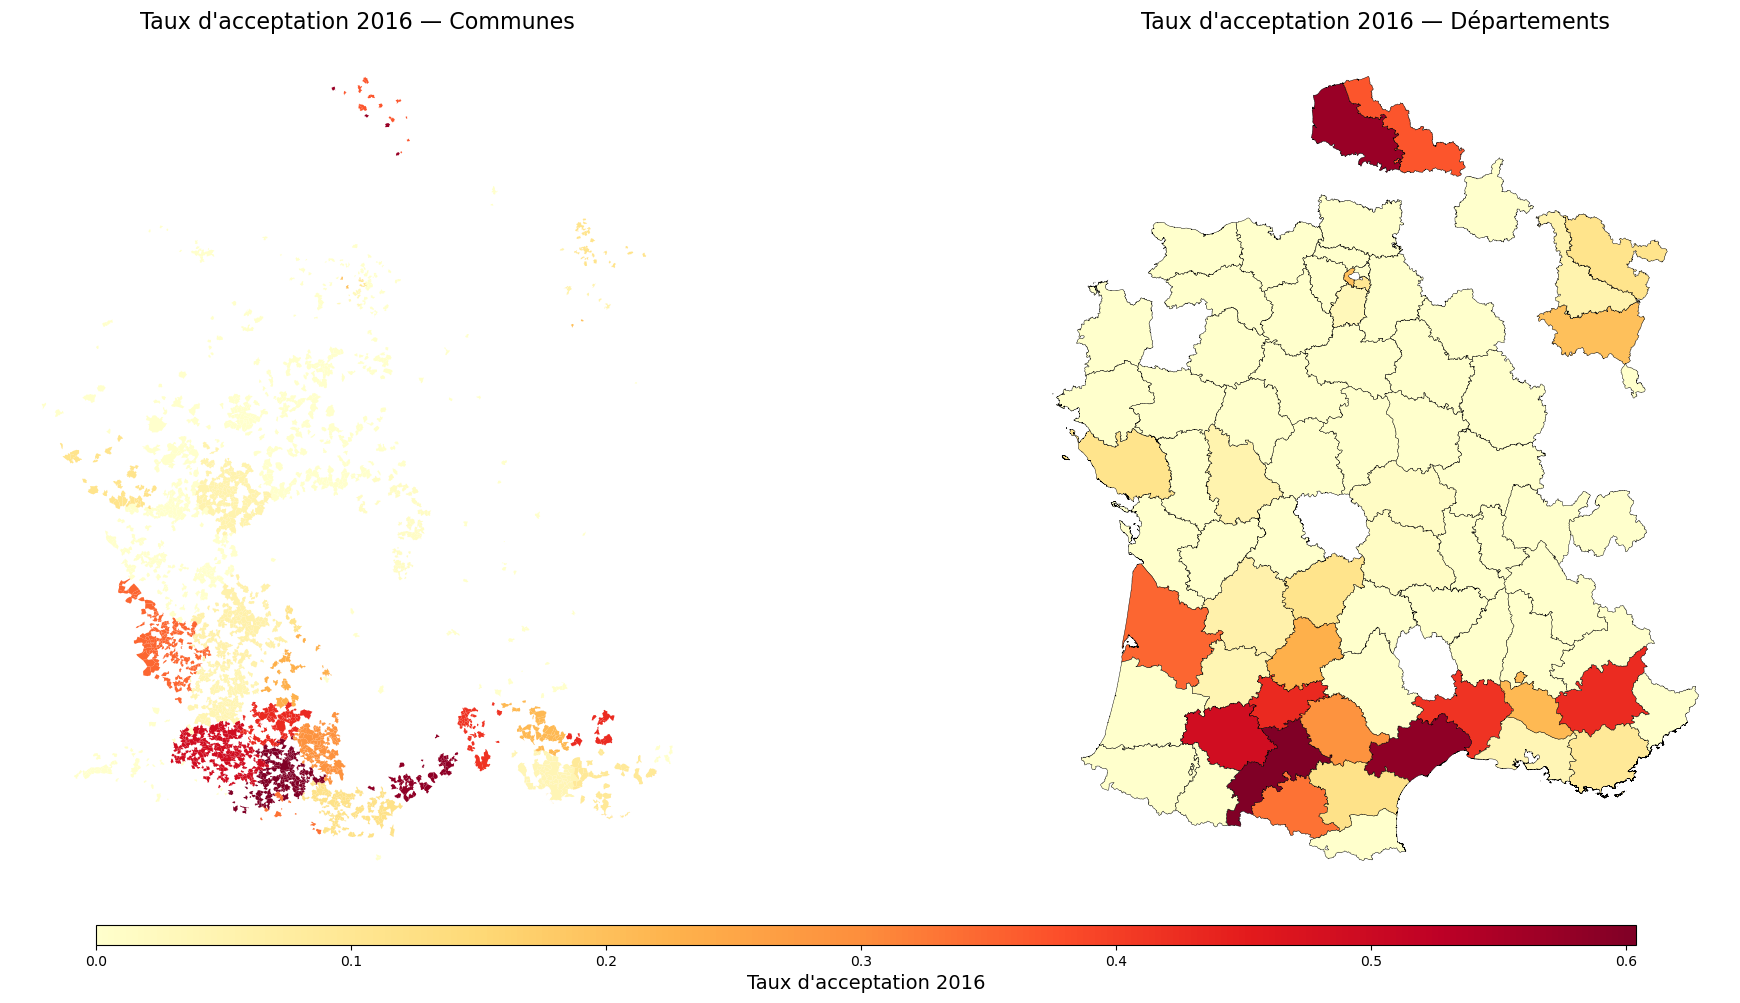


--- TRAITEMENT ANNÉE 2017 ---


C:\Users\HP\AppData\Local\Temp\ipykernel_2164\4076935080.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])


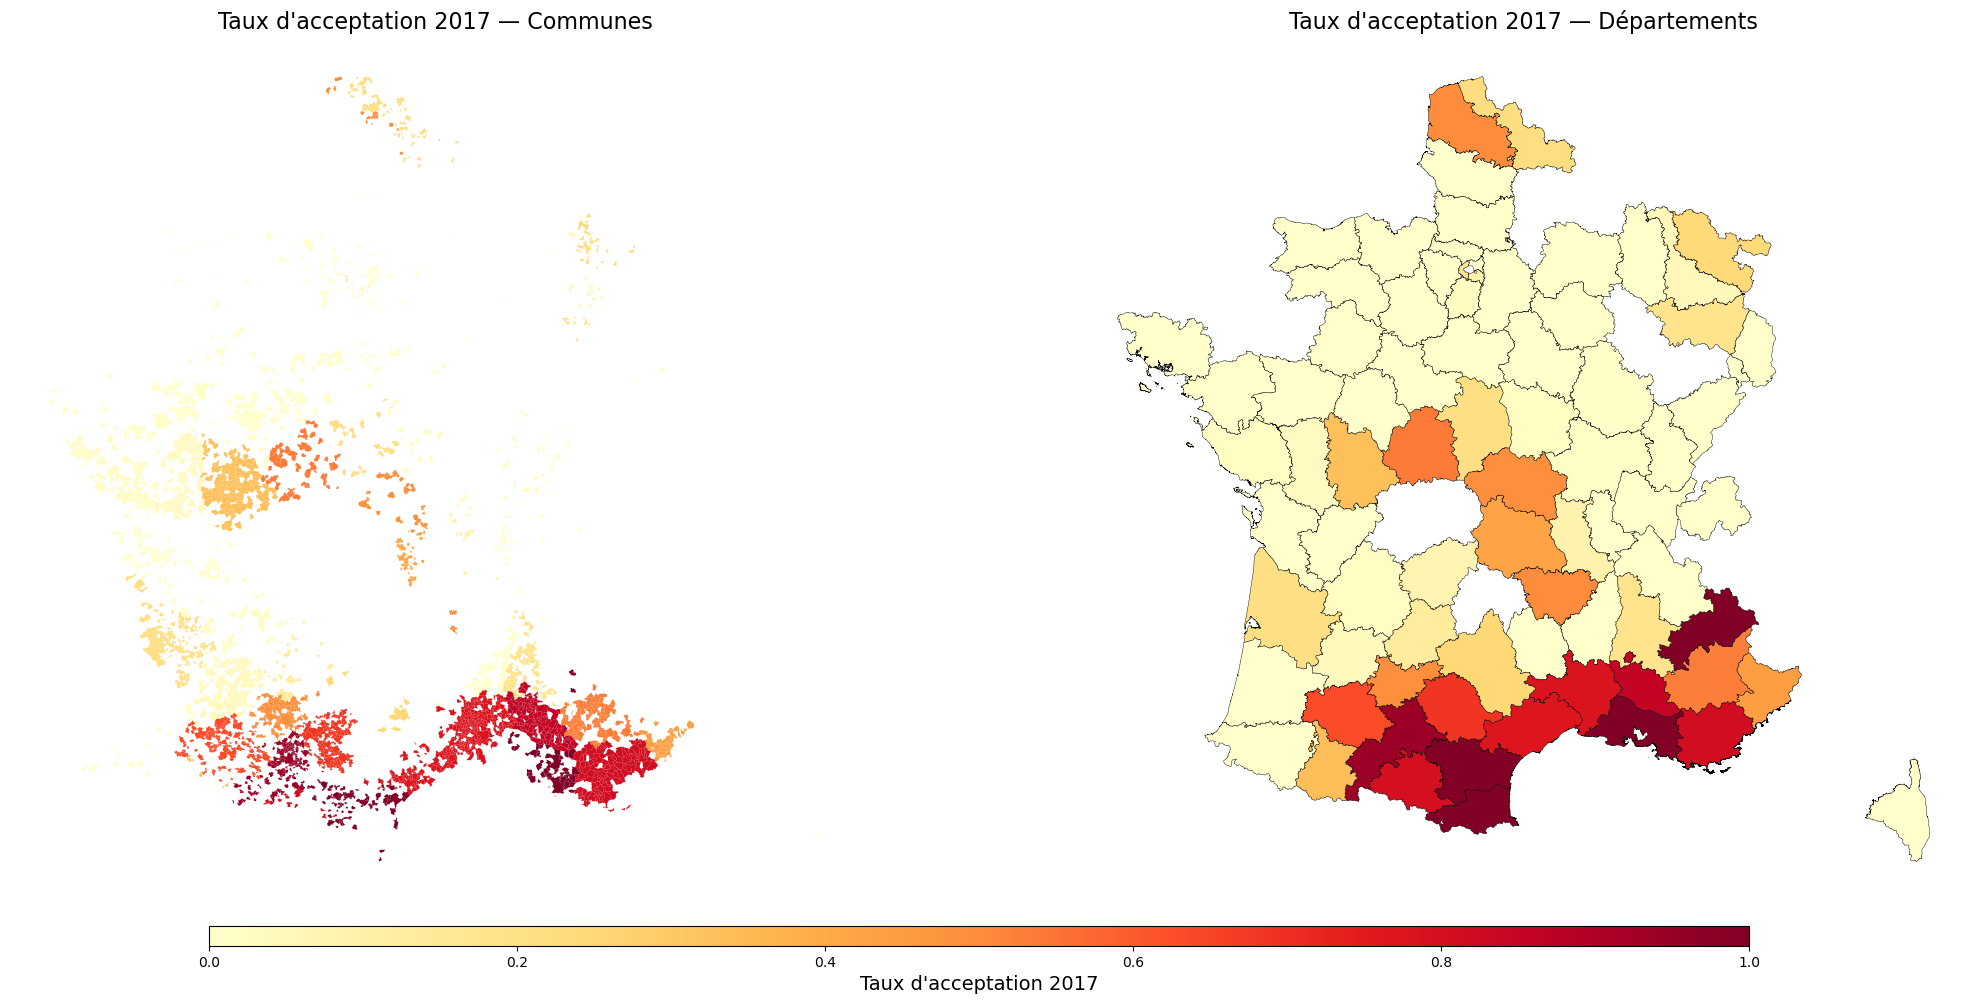


--- TRAITEMENT ANNÉE 2018 ---


C:\Users\HP\AppData\Local\Temp\ipykernel_2164\4076935080.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])


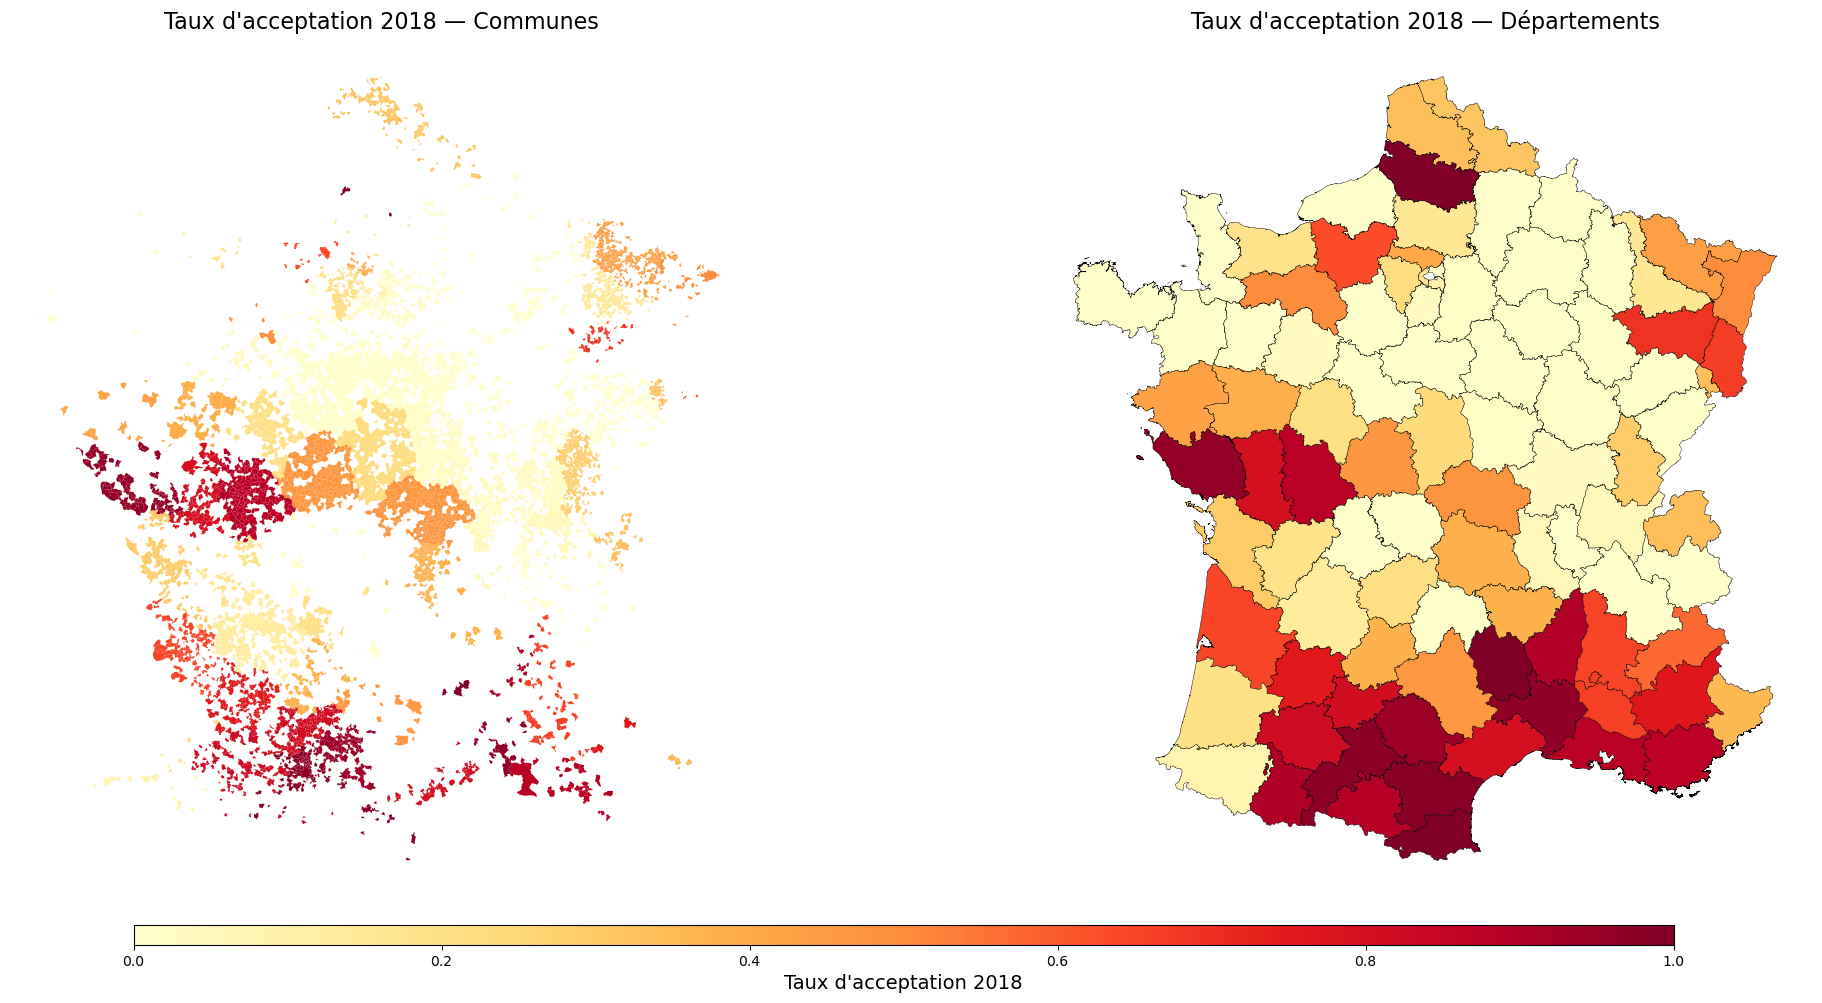


--- TRAITEMENT ANNÉE 2019 ---


C:\Users\HP\AppData\Local\Temp\ipykernel_2164\4076935080.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])


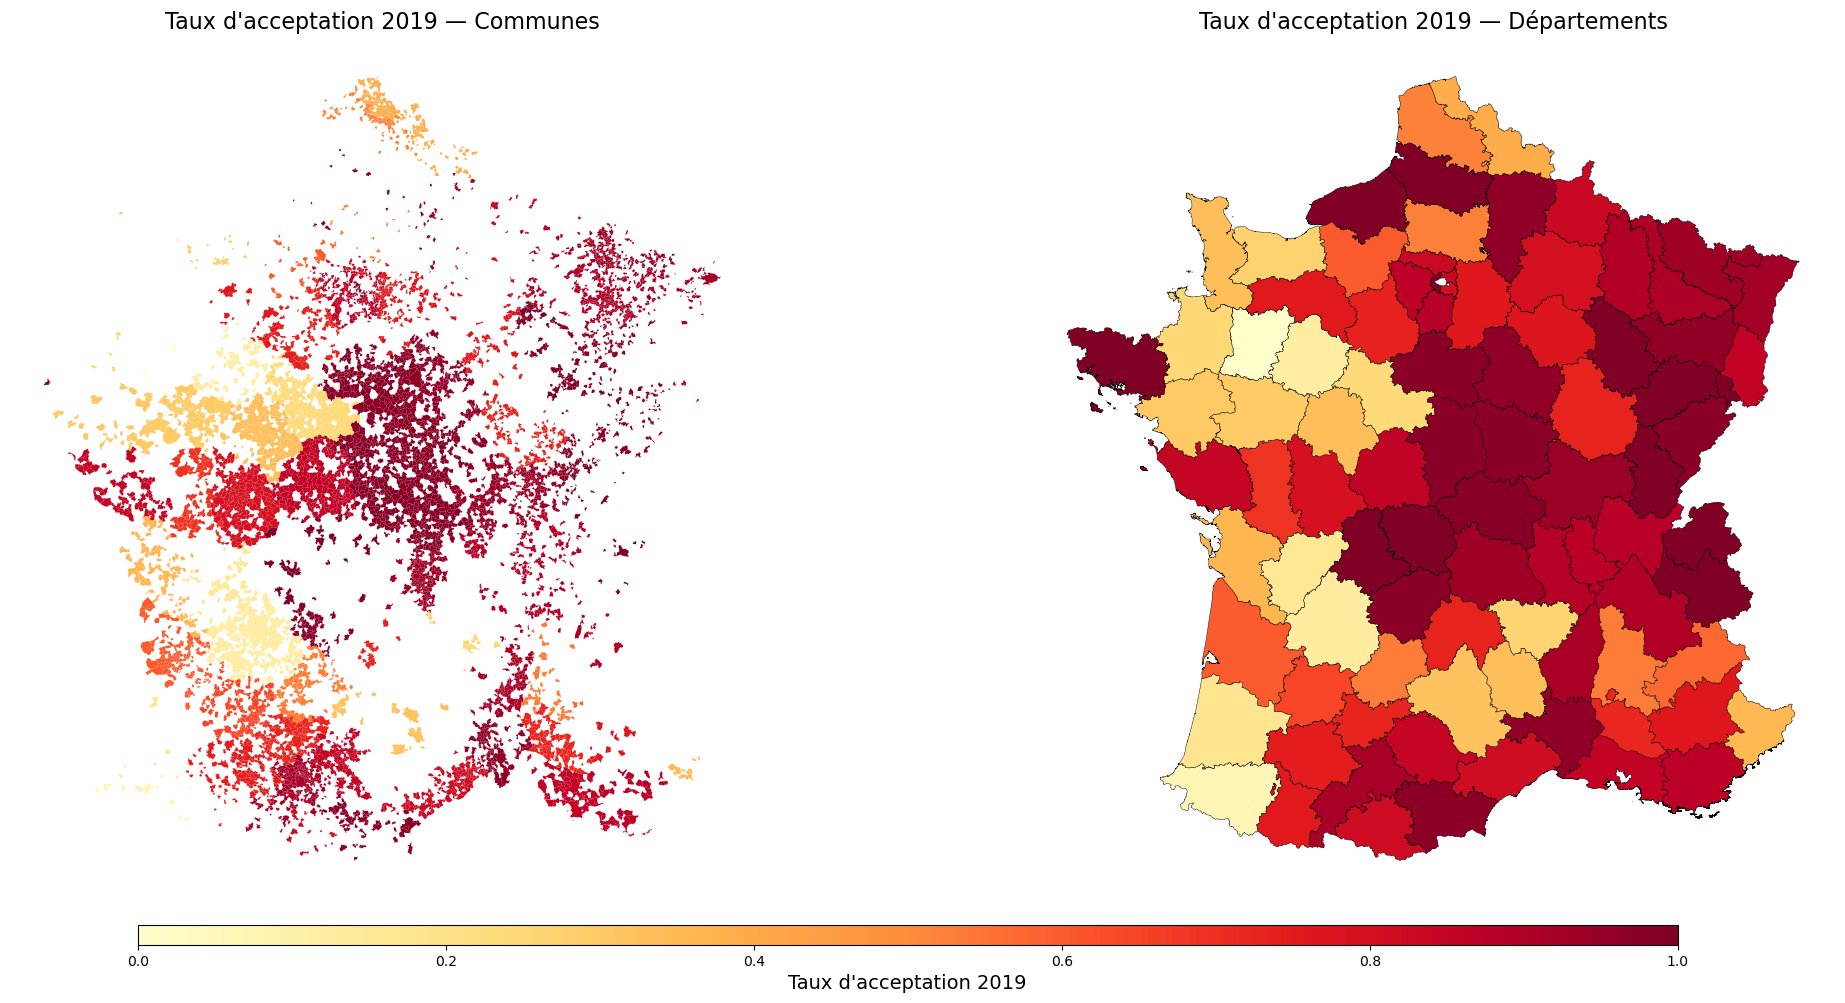


--- TRAITEMENT ANNÉE 2020 ---


C:\Users\HP\AppData\Local\Temp\ipykernel_2164\4076935080.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])


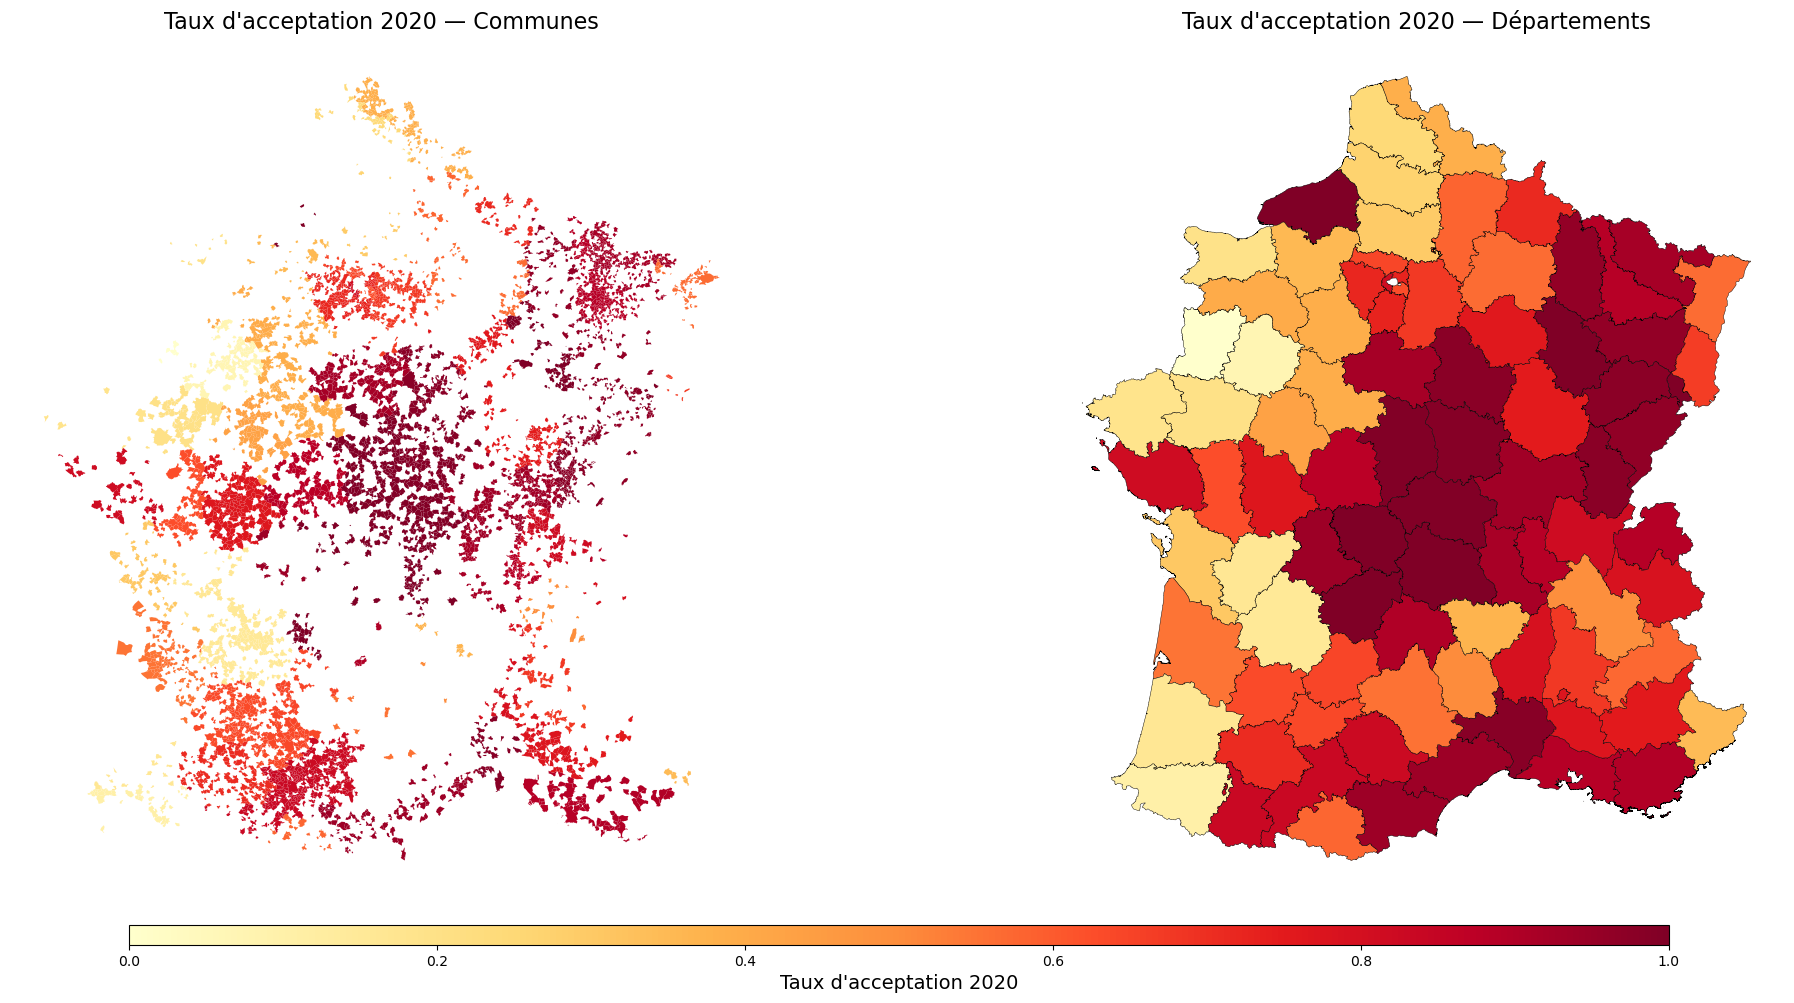


--- TRAITEMENT ANNÉE 2021 ---


C:\Users\HP\AppData\Local\Temp\ipykernel_2164\4076935080.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])


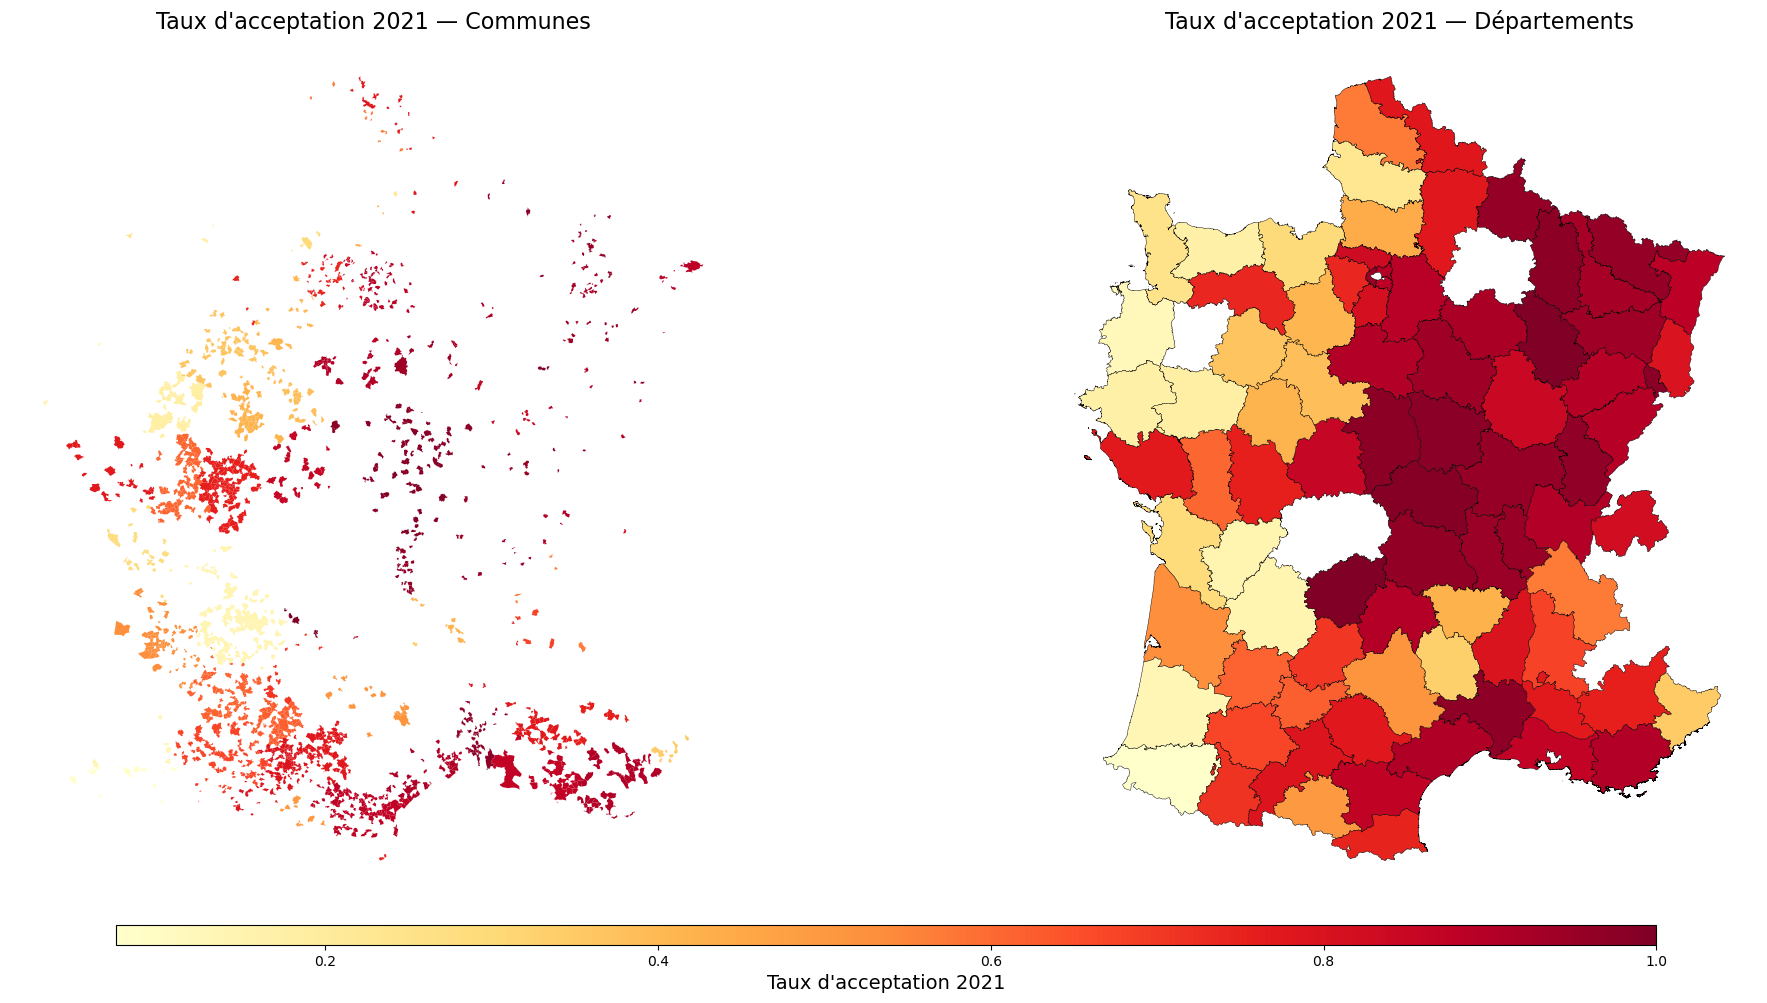


--- TRAITEMENT ANNÉE 2022 ---


C:\Users\HP\AppData\Local\Temp\ipykernel_2164\4076935080.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])


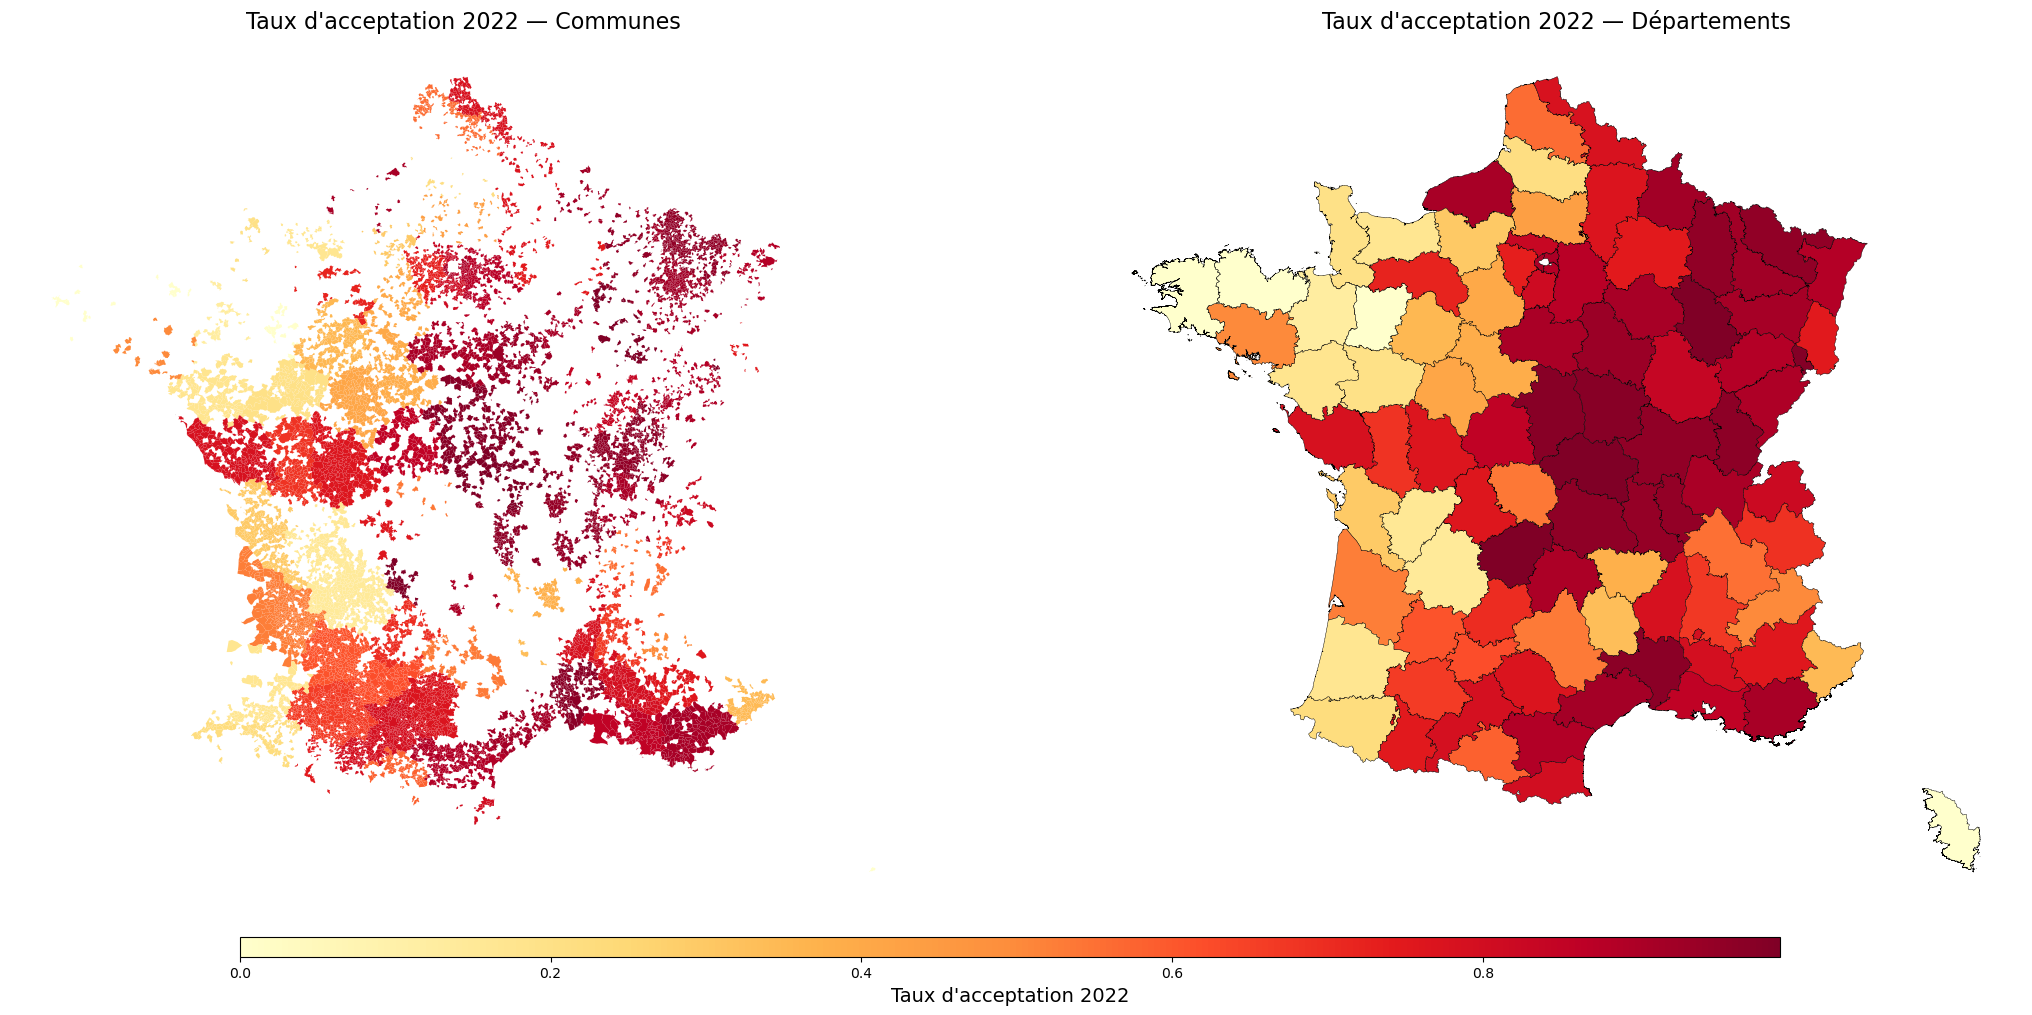


--- TRAITEMENT ANNÉE 2023 ---


C:\Users\HP\AppData\Local\Temp\ipykernel_2164\4076935080.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])


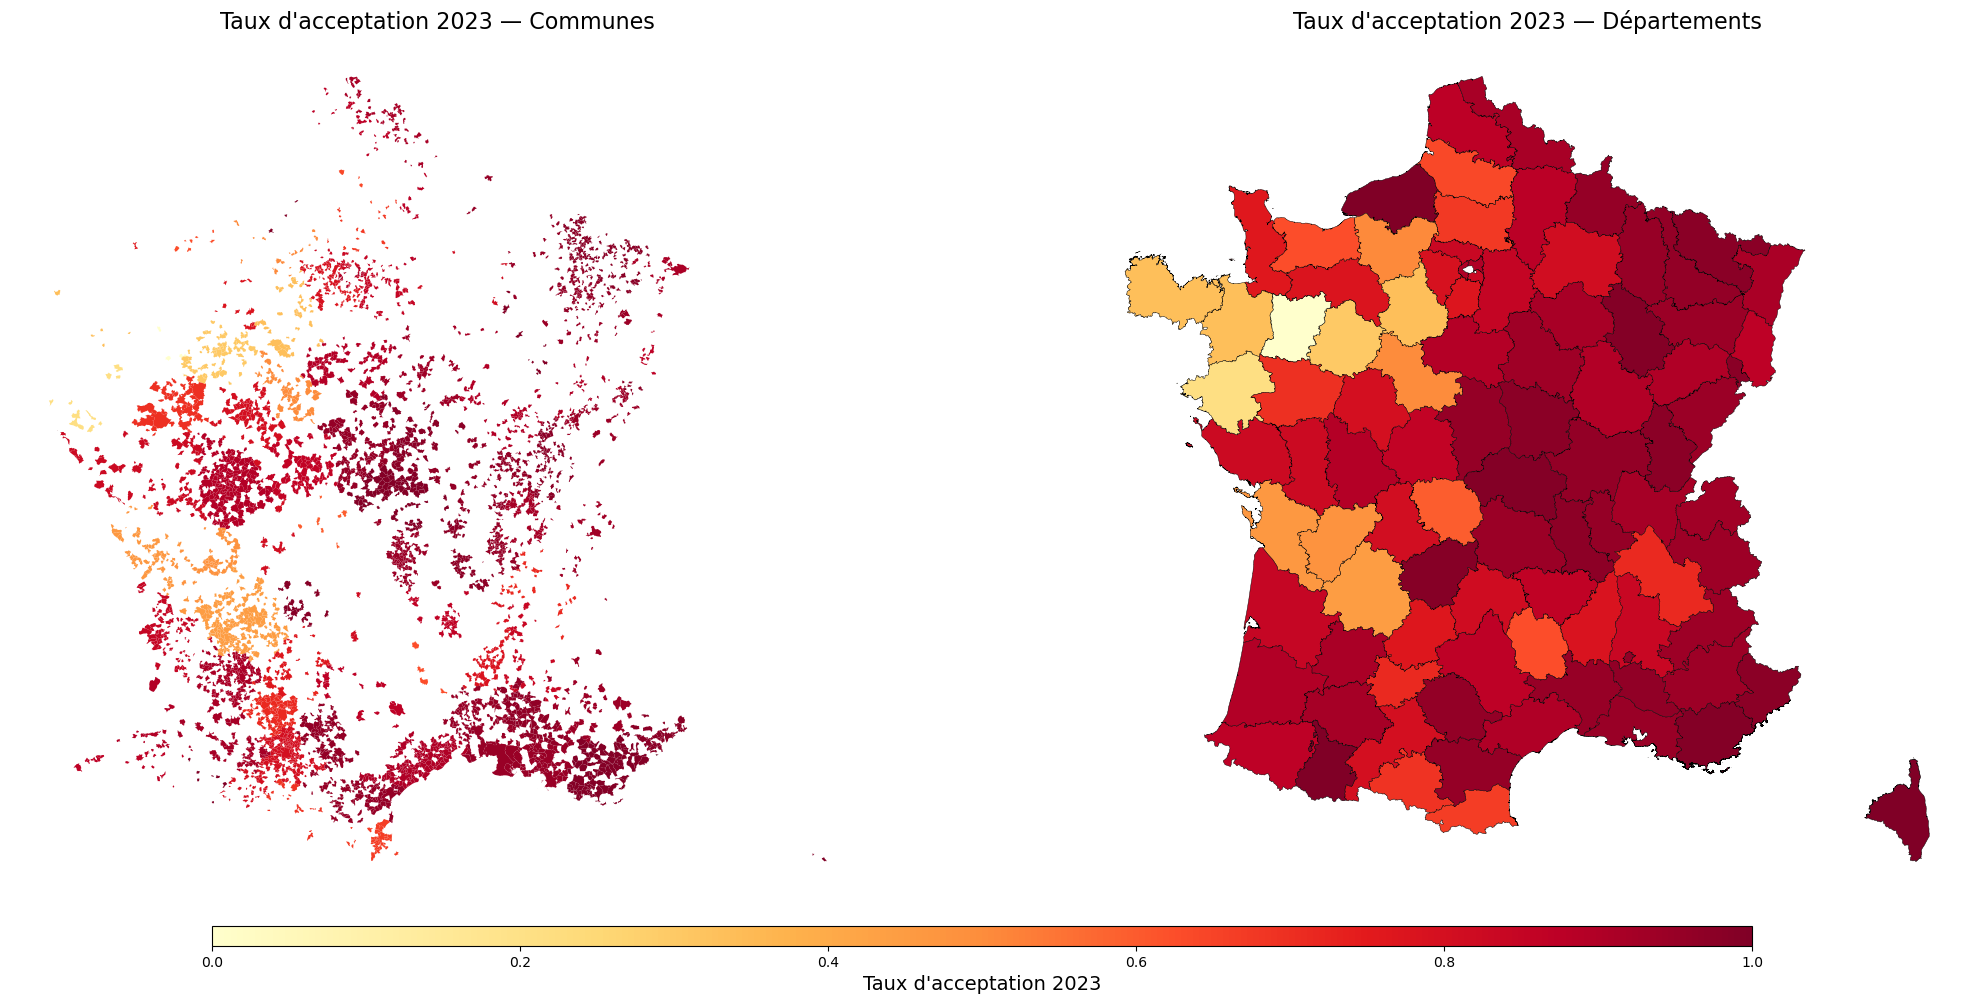


--- TRAITEMENT ANNÉE 2024 ---


C:\Users\HP\AppData\Local\Temp\ipykernel_2164\4076935080.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])


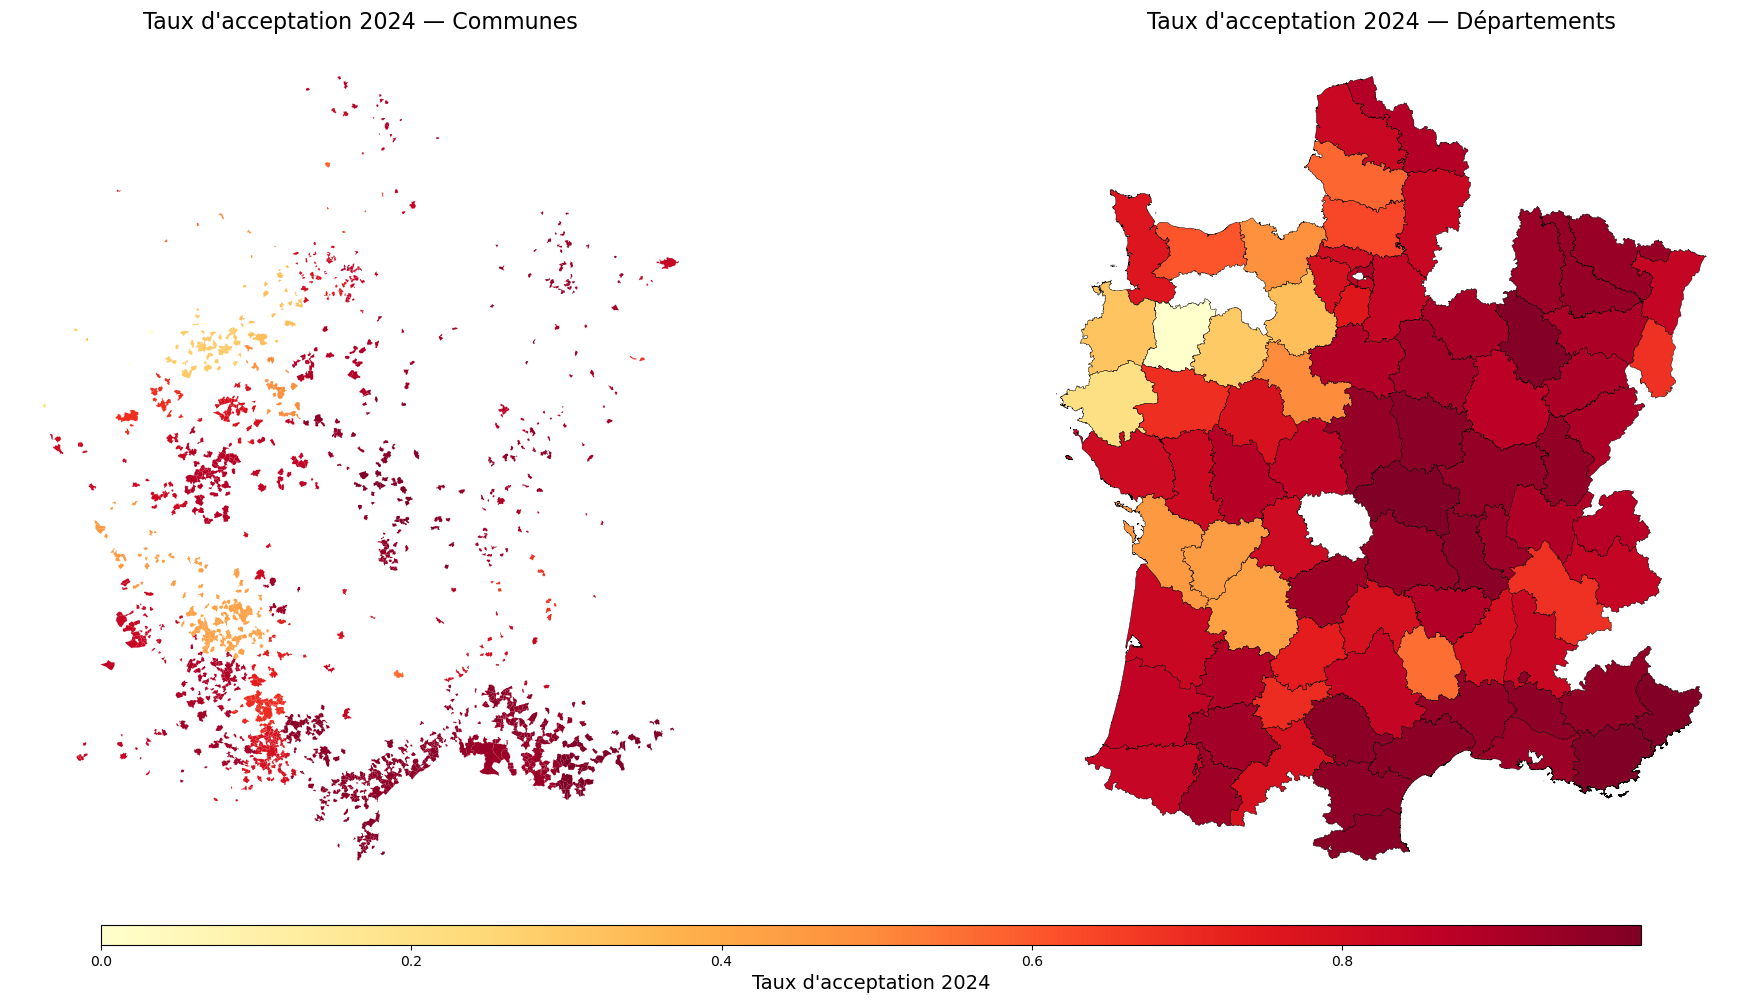


--- TRAITEMENT ANNÉE 2025 ---


C:\Users\HP\AppData\Local\Temp\ipykernel_2164\4076935080.py:63: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf_map_commune.plot(column="accept_rate_dep", cmap=rate_cmap, norm=rate_norm,
C:\Users\HP\AppData\Local\Temp\ipykernel_2164\4076935080.py:69: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf_map_dept.plot(column="accept_rate_dep", cmap=rate_cmap, norm=rate_norm,
C:\Users\HP\AppData\Local\Temp\ipykernel_2164\4076935080.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])


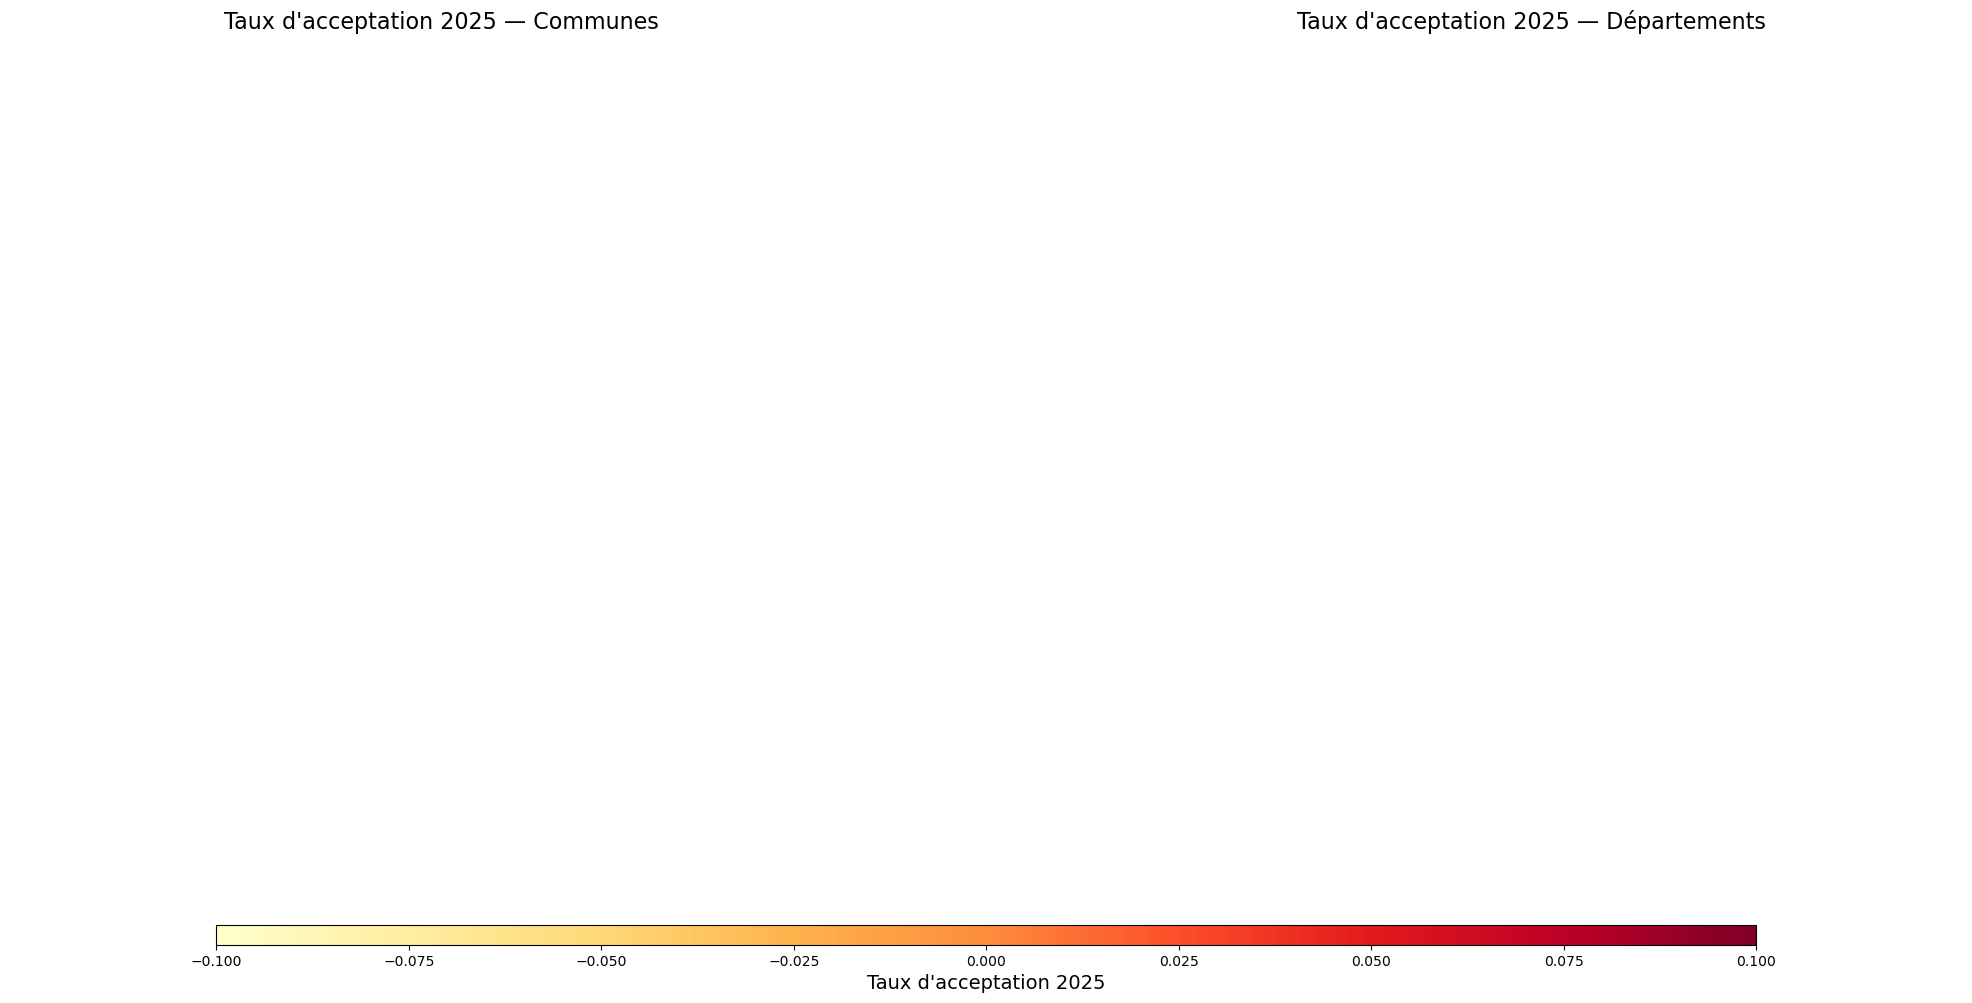

In [ ]:
# Toutes tes années ordonnées de 2025 à 2007 (ordre chronologique croissant)
annees_chronologiques = [2007, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
cartes_taux_acceptation(annees_chronologiques)

